<a href="https://colab.research.google.com/github/mldyharinn/Visi-Komputer/blob/main/JOBSHEET_03_TEKNIK_REGRESI_GAMBAR_4_33_25_2_13_Miladiyah_Arinal_Haq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow version: 2.20.0


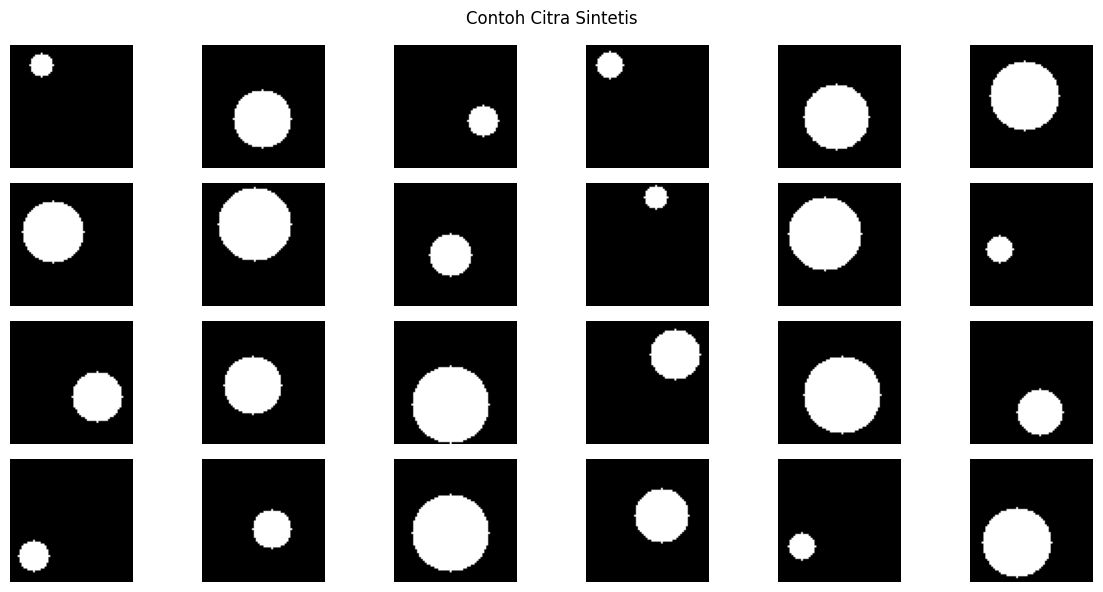

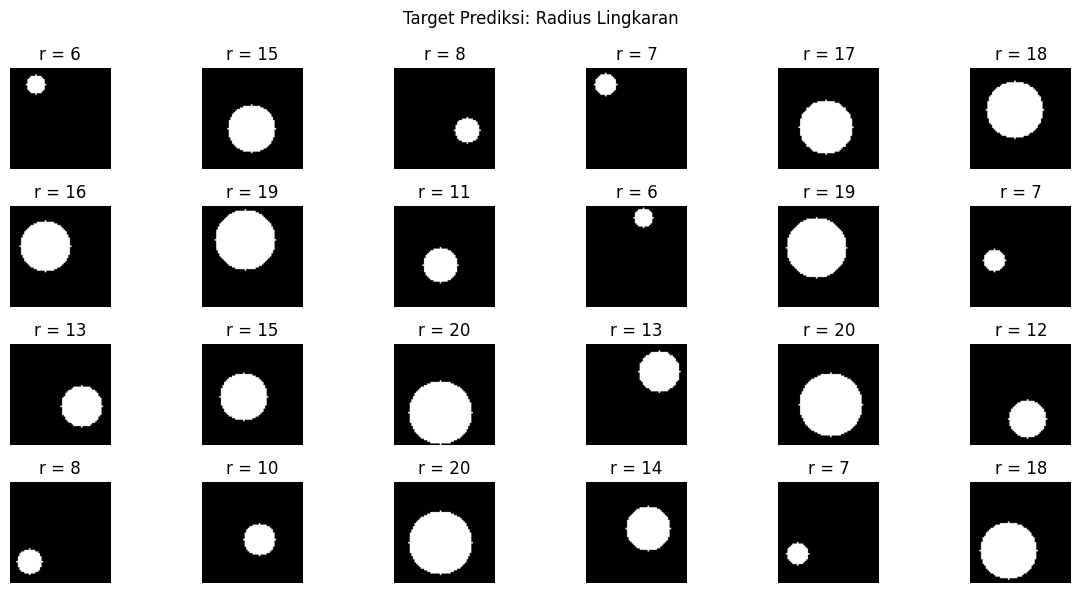


Dataset:
X: (3000, 64, 64, 3)
y: (3000,)
C: (3000, 2)

Pembagian dataset:
Training X: (2400, 64, 64, 3)
Training y: (2400,)
Testing X : (600, 64, 64, 3)
Testing y : (600,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 289ms/step - loss: 45.2545 - mae: 4.9961 - val_loss: 6.5697 - val_mae: 1.8575
Epoch 2/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 275ms/step - loss: 3.3893 - mae: 1.4382 - val_loss: 1.7519 - val_mae: 1.0920
Epoch 3/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 256ms/step - loss: 1.5992 - mae: 1.0303 - val_loss: 1.5896 - val_mae: 1.0047
Epoch 4/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 258ms/step - loss: 1.5630 - mae: 1.0156 - val_loss: 1.4814 - val_mae: 1.0099
Epoch 5/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 255ms/step - loss: 1.5075 - mae: 1.0024 - val_loss: 1.4317 - val_mae: 0.9814
Epoch 6/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 301ms/step - loss: 1.4901 - mae: 0.9951 - val_loss: 1.4359 - val_mae: 0.9681
Epoch 7/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 243ms/step - loss: 1.4899 - mae: 0.9954 - val_loss: 1.4121 - val_mae: 0.9819
Epoch 8/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 250ms/step - loss: 1.5069 - mae: 0.9967 - val_loss: 1.4622 - val_mae: 1.0047
Epoch 9/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 256ms

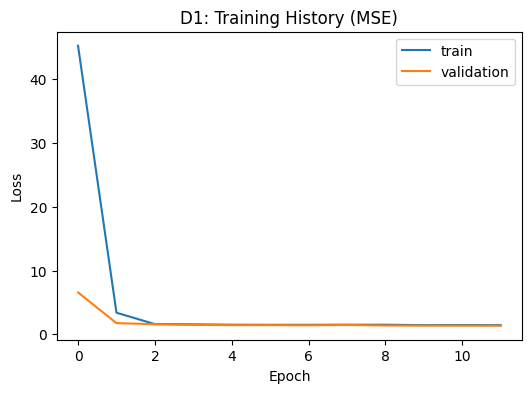


HASIL EVALUASI D1
MAE  = 0.946
RMSE = 1.161
R²   = 0.934


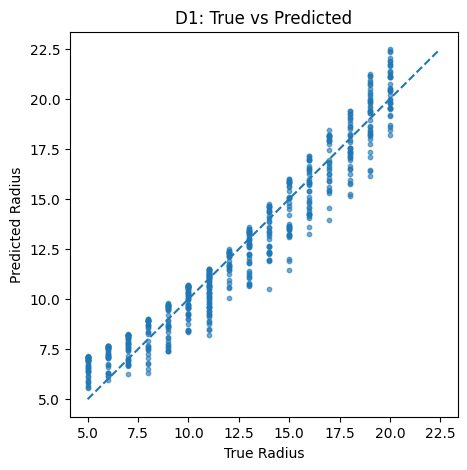

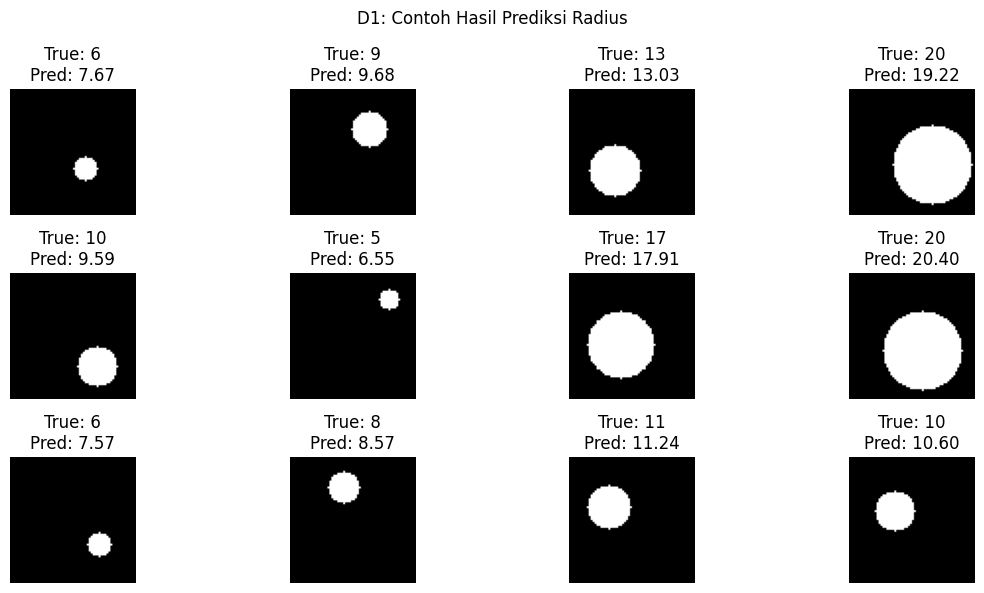

In [6]:
# ============================================================
# PRAKTIKUM 03 - D1
# TEKNIK REGRESI GAMBAR
# REGRESI CITRA SINTETIS
# ============================================================

# ============================================================
# 1. IMPORT LIBRARY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)


# ============================================================
# 2. FUNGSI MEMBUAT CITRA SINTETIS
# ============================================================

def make_sample(img_size=64, min_r=5, max_r=20):

    # Radius acak
    r = np.random.randint(
        min_r,
        max_r + 1
    )

    # Membuat gambar hitam
    img = np.zeros(
        (img_size, img_size),
        dtype=np.uint8
    )

    # Posisi pusat lingkaran
    cx = np.random.randint(
        r,
        img_size - r
    )

    cy = np.random.randint(
        r,
        img_size - r
    )

    # Menggambar lingkaran putih
    cv2.circle(
        img,
        (cx, cy),
        r,
        (255,),
        -1
    )

    # Normalisasi pixel 0-255 menjadi 0-1
    img = (
        img / 255.0
    ).astype(np.float32)

    # Mengubah menjadi 3 channel
    img3 = np.stack(
        [img, img, img],
        axis=-1
    )

    return img3, float(r), (cx, cy)


# ============================================================
# 3. VISUALISASI 24 CONTOH
# ============================================================

N_show = 24

samples = [
    make_sample()
    for _ in range(N_show)
]

imgs = [
    s[0]
    for s in samples
]

rads = [
    s[1]
    for s in samples
]

centers = [
    s[2]
    for s in samples
]


# Visualisasi tanpa label
cols = 6
rows = N_show // cols

plt.figure(figsize=(12, 6))

for i in range(N_show):

    plt.subplot(
        rows,
        cols,
        i + 1
    )

    plt.imshow(
        imgs[i].squeeze(),
        cmap='gray'
    )

    plt.axis('off')

plt.suptitle(
    "Contoh Citra Sintetis"
)

plt.tight_layout()
plt.show()


# Visualisasi dengan radius
plt.figure(figsize=(12, 6))

for i in range(N_show):

    plt.subplot(
        rows,
        cols,
        i + 1
    )

    plt.imshow(
        imgs[i].squeeze(),
        cmap='gray'
    )

    plt.title(
        f"r = {int(rads[i])}"
    )

    plt.axis('off')

plt.suptitle(
    "Target Prediksi: Radius Lingkaran"
)

plt.tight_layout()
plt.show()


# ============================================================
# 4. MEMBUAT DATASET
# ============================================================

N = 3000

X, y, C = zip(
    *[
        make_sample()
        for _ in range(N)
    ]
)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.float32
)

C = np.array(C)

print("\nDataset:")
print("X:", X.shape)
print("y:", y.shape)
print("C:", C.shape)


# ============================================================
# 5. TRAIN TEST SPLIT
# ============================================================

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nPembagian dataset:")
print("Training X:", Xtr.shape)
print("Training y:", ytr.shape)
print("Testing X :", Xte.shape)
print("Testing y :", yte.shape)


# ============================================================
# 6. MEMBUAT MODEL CNN
# ============================================================

model = models.Sequential([

    layers.Input(
        shape=(64, 64, 3)
    ),

    layers.Conv2D(
        32,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        3,
        activation='relu'
    ),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        64,
        activation='relu'
    ),

    layers.Dense(1)
])


# ============================================================
# 7. MODEL SUMMARY
# ============================================================

model.summary()


# ============================================================
# 8. COMPILE MODEL
# ============================================================

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# ============================================================
# 9. TRAINING
# ============================================================

history = model.fit(
    Xtr,
    ytr,
    validation_data=(Xte, yte),
    epochs=12,
    batch_size=64,
    verbose=1
)


# ============================================================
# 10. TRAINING HISTORY
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='validation'
)

plt.title(
    "D1: Training History (MSE)"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()


# ============================================================
# 11. PREDIKSI DATA TESTING
# ============================================================

y_pred = model.predict(
    Xte,
    verbose=0
).ravel()


# ============================================================
# 12. EVALUASI
# ============================================================

mae = mean_absolute_error(
    yte,
    y_pred
)

rmse = float(
    np.sqrt(
        np.mean(
            (yte - y_pred) ** 2
        )
    )
)

r2 = r2_score(
    yte,
    y_pred
)


print("\n================================")
print("HASIL EVALUASI D1")
print("================================")

print(
    f"MAE  = {mae:.3f}"
)

print(
    f"RMSE = {rmse:.3f}"
)

print(
    f"R²   = {r2:.3f}"
)


# ============================================================
# 13. TRUE VS PREDICTED
# ============================================================

plt.figure(figsize=(5, 5))

plt.scatter(
    yte,
    y_pred,
    s=10,
    alpha=0.6
)

lims = [
    min(
        yte.min(),
        y_pred.min()
    ),
    max(
        yte.max(),
        y_pred.max()
    )
]

plt.plot(
    lims,
    lims,
    '--'
)

plt.xlabel(
    "True Radius"
)

plt.ylabel(
    "Predicted Radius"
)

plt.title(
    "D1: True vs Predicted"
)

plt.show()


# ============================================================
# 14. CONTOH HASIL PREDIKSI
# ============================================================

N_test_show = 12

indices = np.random.choice(
    len(Xte),
    N_test_show,
    replace=False
)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(indices):

    plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(
        Xte[idx].squeeze(),
        cmap='gray'
    )

    true_radius = yte[idx]
    predicted_radius = y_pred[idx]

    plt.title(
        f"True: {true_radius:.0f}\n"
        f"Pred: {predicted_radius:.2f}"
    )

    plt.axis('off')

plt.suptitle(
    "D1: Contoh Hasil Prediksi Radius"
)

plt.tight_layout()
plt.show()

TensorFlow version: 2.20.0
Jumlah contoh gambar: 24


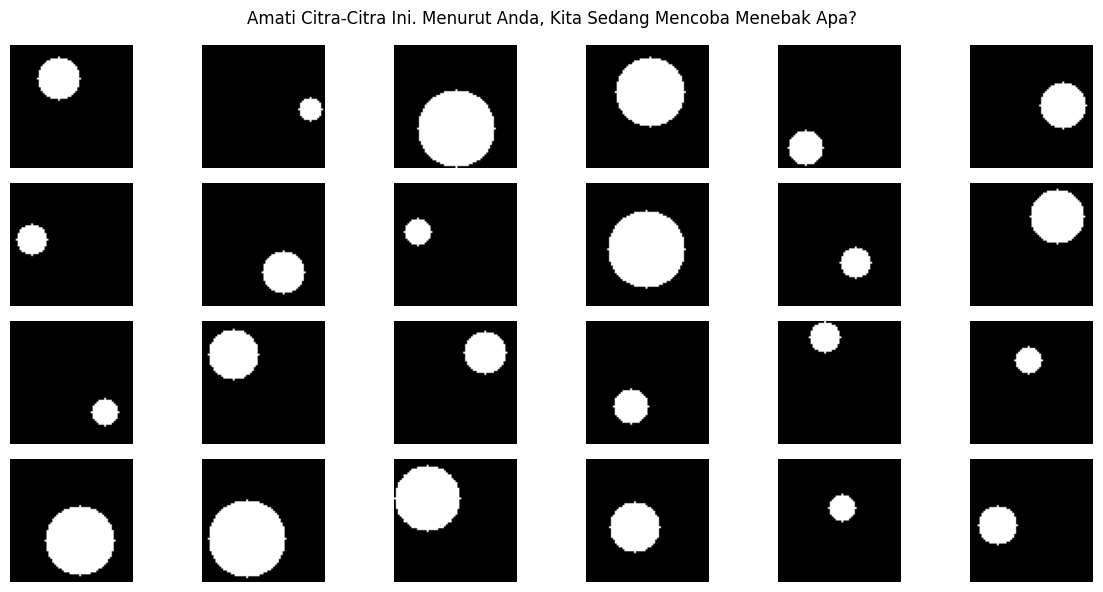

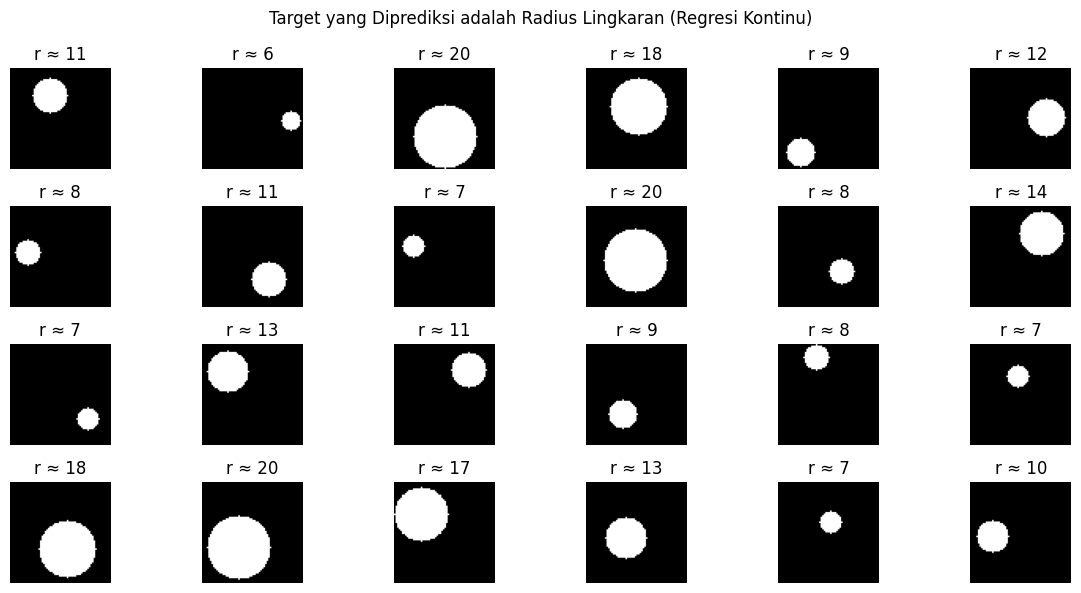


===== DATASET =====
X shape: (3000, 64, 64, 3)
y shape: (3000,)
C shape: (3000, 2)

===== PEMBAGIAN DATA =====
Training X: (2400, 64, 64, 3)
Training y: (2400,)
Testing X: (600, 64, 64, 3)
Testing y: (600,)

===== MODEL SUMMARY =====


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)


===== TRAINING D1 =====
Epoch 1/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 251ms/step - loss: 51.2302 - mae: 5.2790 - val_loss: 3.8055 - val_mae: 1.4418
Epoch 2/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 239ms/step - loss: 2.2548 - mae: 1.1732 - val_loss: 1.6895 - val_mae: 1.0490
Epoch 3/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 256ms/step - loss: 1.6608 - mae: 1.0667 - val_loss: 1.6377 - val_mae: 1.0334
Epoch 4/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 255ms/step - loss: 1.6155 - mae: 1.0448 - val_loss: 1.6498 - val_mae: 1.0798
Epoch 5/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 257ms/step - loss: 1.5845 - mae: 1.0404 - val_loss: 1.5618 - val_mae: 1.0318
Epoch 6/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 257ms/step - loss: 1.5621 - mae: 1.0284 - val_loss: 1.5286 - val_mae: 1.0111
Epoch 7/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 267ms/step - loss: 1.5256 - mae: 1.0188 - val_loss: 1.5290 - val_mae: 1.0072
Epoch 8/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 242ms/step - loss: 1.5488 - mae: 1.0237 - val_loss: 1.5005 - val_mae: 0.9948
Epoch 9/12
38/38 ━━━━━━

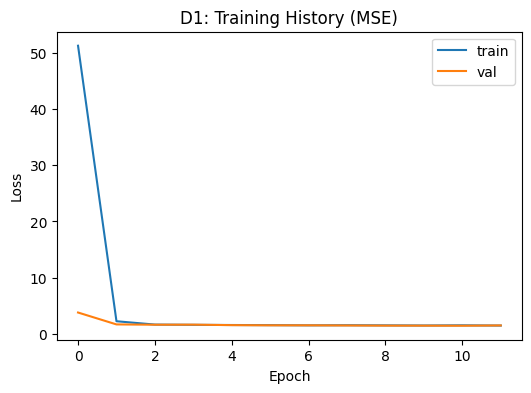


HASIL EVALUASI D1
MAE  = 1.034
RMSE = 1.229
R²   = 0.925


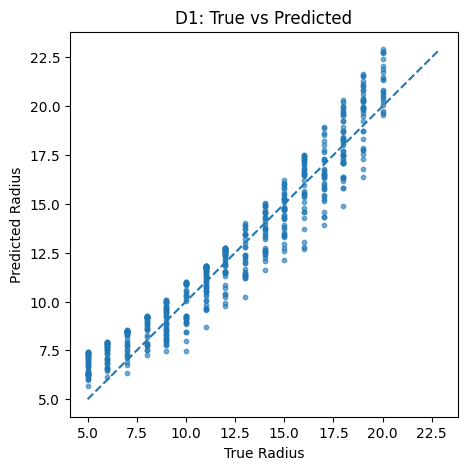

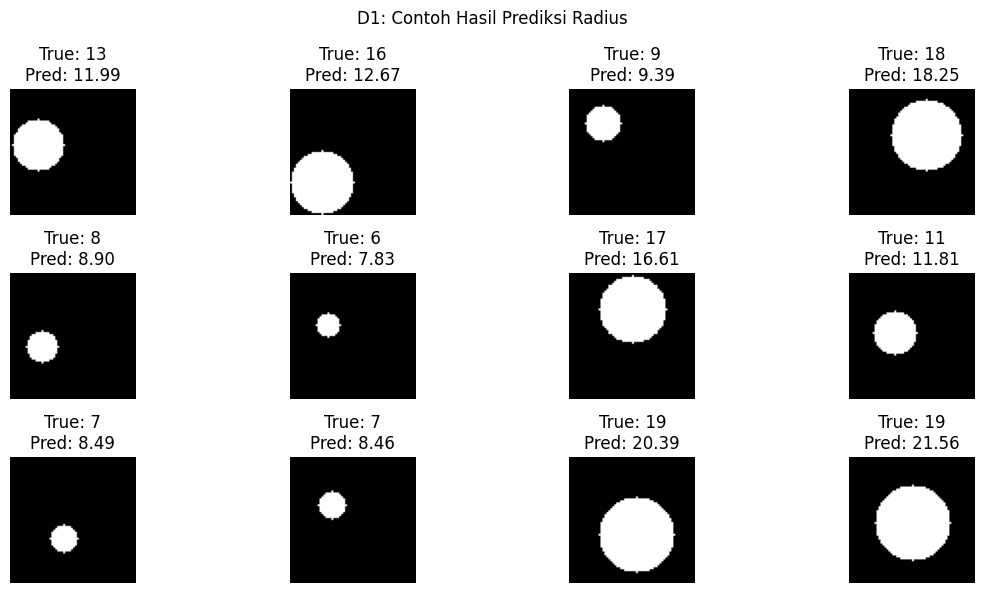



TANTANGAN 1 - RADIUS 8 SAMPAI 28
X: (3000, 64, 64, 3)
y: (3000,)
Radius minimum: 8.0
Radius maksimum: 28.0
Epoch 1/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 299ms/step - loss: 106.8125 - mae: 7.7964 - val_loss: 10.4032 - val_mae: 2.6230
Epoch 2/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 259ms/step - loss: 3.2147 - mae: 1.4119 - val_loss: 1.2811 - val_mae: 0.9409
Epoch 3/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 255ms/step - loss: 1.1510 - mae: 0.8711 - val_loss: 1.1062 - val_mae: 0.8662
Epoch 4/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 292ms/step - loss: 1.1078 - mae: 0.8570 - val_loss: 1.1371 - val_mae: 0.8797
Epoch 5/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 270ms/step - loss: 1.0546 - mae: 0.8335 - val_loss: 1.0538 - val_mae: 0.8469
Epoch 6/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 244ms/step - loss: 1.0588 - mae: 0.8354 - val_loss: 1.0278 - val_mae: 0.8415
Epoch 7/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 245ms/step - loss: 1.0164 - mae: 0.8162 - val_loss: 1.0736 - val_mae: 0.8412
Epoch 8/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 276ms/step - l

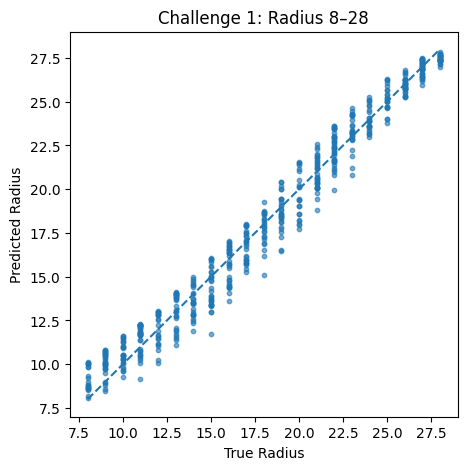



TANTANGAN 2 - GAUSSIAN NOISE


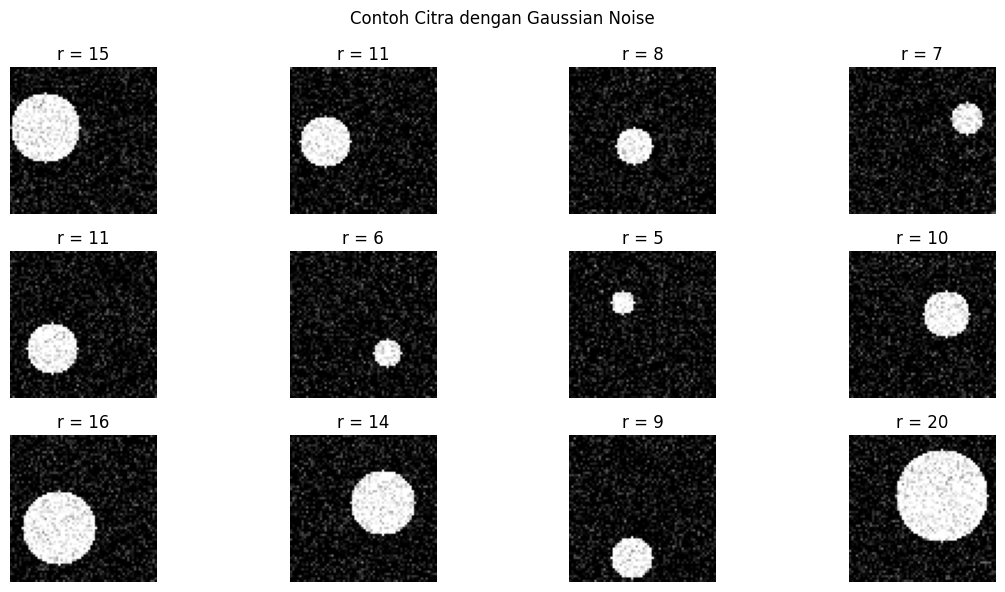

Epoch 1/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 279ms/step - loss: 51.5493 - mae: 5.2704 - val_loss: 3.1769 - val_mae: 1.5205
Epoch 2/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 293ms/step - loss: 1.9523 - mae: 1.1333 - val_loss: 1.2902 - val_mae: 0.9390
Epoch 3/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 256ms/step - loss: 1.4632 - mae: 0.9798 - val_loss: 1.2200 - val_mae: 0.9061
Epoch 4/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 275ms/step - loss: 1.4266 - mae: 0.9646 - val_loss: 1.2128 - val_mae: 0.9013
Epoch 5/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 271ms/step - loss: 1.4262 - mae: 0.9661 - val_loss: 1.2272 - val_mae: 0.9080
Epoch 6/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 275ms/step - loss: 1.4016 - mae: 0.9572 - val_loss: 1.2122 - val_mae: 0.8884
Epoch 7/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 275ms/step - loss: 1.4142 - mae: 0.9589 - val_loss: 1.2446 - val_mae: 0.9128
Epoch 8/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - loss: 1.3912 - mae: 0.9519 - val_loss: 1.2325 - val_mae: 0.9081
Epoch 9/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 257ms

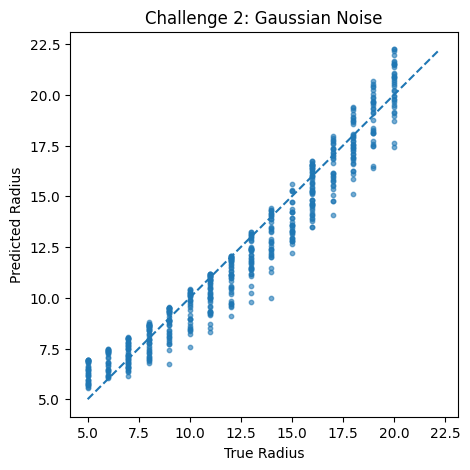



TANTANGAN 3 - MULTI-OUTPUT
X shape: (3000, 64, 64, 3)
y shape: (3000, 3)
Contoh target: [ 5. 36. 35.]
Format target: [radius, cx, cy]


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,699 (397.26 KB)

 Trainable params: 101,699 (397.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 269ms/step - loss: 414.4612 - mae: 15.4763 - val_loss: 217.1043 - val_mae: 10.3857
Epoch 2/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 264ms/step - loss: 127.8907 - mae: 8.1263 - val_loss: 89.6711 - val_mae: 7.4868
Epoch 3/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 264ms/step - loss: 86.8635 - mae: 7.3217 - val_loss: 83.6597 - val_mae: 7.1272
Epoch 4/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 254ms/step - loss: 81.2793 - mae: 6.9518 - val_loss: 80.0994 - val_mae: 6.9333
Epoch 5/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 247ms/step - loss: 75.2488 - mae: 6.5484 - val_loss: 72.1088 - val_mae: 6.2828
Epoch 6/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 261ms/step - loss: 68.0879 - mae: 5.9503 - val_loss: 63.6140 - val_mae: 5.7373
Epoch 7/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 265ms/step - loss: 60.1320 - mae: 5.5269 - val_loss: 53.8396 - val_mae: 5.3224
Epoch 8/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 267ms/step - loss: 48.0713 - mae: 4.9135 - val_loss: 41.4712 - val_mae: 4.6093
Epoch 9/12
38/38 ━━━━━━━━━━

In [7]:
# ============================================================
# PRAKTIKUM 03 - TEKNIK REGRESI GAMBAR
# D1 - REGRESI CITRA SINTETIS
# + TANTANGAN MINI D1
# ============================================================


# ============================================================
# 1. IMPORT LIBRARY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)


# ============================================================
# D1 - REGRESI CITRA SINTETIS
# ============================================================

# ============================================================
# 2. GENERATOR CITRA SINTETIS
# ============================================================

def make_sample(
    img_size=64,
    min_r=5,
    max_r=20
):

    # Membuat radius secara acak
    r = np.random.randint(
        min_r,
        max_r + 1
    )

    # Membuat background hitam
    img = np.zeros(
        (img_size, img_size),
        dtype=np.uint8
    )

    # Menentukan posisi pusat lingkaran
    cx = np.random.randint(
        r,
        img_size - r
    )

    cy = np.random.randint(
        r,
        img_size - r
    )

    # Menggambar lingkaran putih
    cv2.circle(
        img,
        (cx, cy),
        r,
        (255,),
        -1
    )

    # Normalisasi pixel 0-255 menjadi 0-1
    img = (
        img / 255.0
    ).astype(np.float32)

    # Mengubah grayscale menjadi 3 channel
    img3 = np.stack(
        [img, img, img],
        axis=-1
    )

    return img3, float(r), (cx, cy)


# ============================================================
# 3. MEMBUAT 24 CONTOH GAMBAR
# ============================================================

N_show = 24

samples = [
    make_sample()
    for _ in range(N_show)
]

imgs = [
    s[0]
    for s in samples
]

rads = [
    s[1]
    for s in samples
]

centers = [
    s[2]
    for s in samples
]

print(
    "Jumlah contoh gambar:",
    len(imgs)
)


# ============================================================
# 4. VISUALISASI TANPA LABEL
# ============================================================

cols = 6
rows = N_show // cols

plt.figure(
    figsize=(12, 6)
)

for i in range(N_show):

    plt.subplot(
        rows,
        cols,
        i + 1
    )

    plt.imshow(
        imgs[i].squeeze(),
        cmap='gray'
    )

    plt.axis('off')

plt.suptitle(
    "Amati Citra-Citra Ini. "
    "Menurut Anda, Kita Sedang Mencoba Menebak Apa?"
)

plt.tight_layout()
plt.show()


# ============================================================
# 5. VISUALISASI DENGAN LABEL RADIUS
# ============================================================

plt.figure(
    figsize=(12, 6)
)

for i in range(N_show):

    plt.subplot(
        rows,
        cols,
        i + 1
    )

    plt.imshow(
        imgs[i].squeeze(),
        cmap='gray'
    )

    plt.title(
        f"r ≈ {int(rads[i])}"
    )

    plt.axis('off')

plt.suptitle(
    "Target yang Diprediksi adalah Radius Lingkaran "
    "(Regresi Kontinu)"
)

plt.tight_layout()
plt.show()


# ============================================================
# 6. MEMBUAT DATASET 3000 GAMBAR
# ============================================================

N = 3000

X, y, C = zip(
    *[
        make_sample()
        for _ in range(N)
    ]
)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.float32
)

C = np.array(C)

print("\n===== DATASET =====")

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

print(
    "C shape:",
    C.shape
)


# ============================================================
# 7. TRAIN TEST SPLIT
# ============================================================

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\n===== PEMBAGIAN DATA =====")

print(
    "Training X:",
    Xtr.shape
)

print(
    "Training y:",
    ytr.shape
)

print(
    "Testing X:",
    Xte.shape
)

print(
    "Testing y:",
    yte.shape
)


# ============================================================
# 8. MEMBUAT MODEL CNN
# ============================================================

model = models.Sequential([

    layers.Input(
        (64, 64, 3)
    ),

    layers.Conv2D(
        32,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        3,
        activation='relu'
    ),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        64,
        activation='relu'
    ),

    # Output 1 angka = radius
    layers.Dense(1)
])


# ============================================================
# 9. MODEL SUMMARY
# ============================================================

print("\n===== MODEL SUMMARY =====")

model.summary()


# ============================================================
# 10. COMPILE MODEL
# ============================================================

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# ============================================================
# 11. TRAINING
# ============================================================

print("\n===== TRAINING D1 =====")

history = model.fit(
    Xtr,
    ytr,
    validation_data=(
        Xte,
        yte
    ),
    epochs=12,
    batch_size=64,
    verbose=1
)


# ============================================================
# 12. GRAFIK TRAINING HISTORY
# ============================================================

plt.figure(
    figsize=(6, 4)
)

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='val'
)

plt.title(
    "D1: Training History (MSE)"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.show()


# ============================================================
# 13. PREDIKSI DATA TESTING
# ============================================================

y_pred = model.predict(
    Xte,
    verbose=0
).ravel()


# ============================================================
# 14. EVALUASI MAE
# ============================================================

mae = mean_absolute_error(
    yte,
    y_pred
)


# ============================================================
# 15. EVALUASI RMSE
# ============================================================

rmse = float(
    np.sqrt(
        np.mean(
            (yte - y_pred) ** 2
        )
    )
)


# ============================================================
# 16. EVALUASI R²
# ============================================================

r2 = r2_score(
    yte,
    y_pred
)


# ============================================================
# 17. HASIL EVALUASI D1
# ============================================================

print("\n================================")
print("HASIL EVALUASI D1")
print("================================")

print(
    f"MAE  = {mae:.3f}"
)

print(
    f"RMSE = {rmse:.3f}"
)

print(
    f"R²   = {r2:.3f}"
)


# ============================================================
# 18. TRUE VS PREDICTED
# ============================================================

plt.figure(
    figsize=(5, 5)
)

plt.scatter(
    yte,
    y_pred,
    s=10,
    alpha=0.6
)

lims = [
    min(
        yte.min(),
        y_pred.min()
    ),
    max(
        yte.max(),
        y_pred.max()
    )
]

plt.plot(
    lims,
    lims,
    '--'
)

plt.xlabel(
    "True Radius"
)

plt.ylabel(
    "Predicted Radius"
)

plt.title(
    "D1: True vs Predicted"
)

plt.show()


# ============================================================
# 19. CONTOH PREDIKSI
# ============================================================

N_test_show = 12

indices = np.random.choice(
    len(Xte),
    N_test_show,
    replace=False
)

plt.figure(
    figsize=(12, 6)
)

for i, idx in enumerate(indices):

    plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(
        Xte[idx].squeeze(),
        cmap='gray'
    )

    true_radius = yte[idx]

    predicted_radius = y_pred[idx]

    plt.title(
        f"True: {true_radius:.0f}\n"
        f"Pred: {predicted_radius:.2f}"
    )

    plt.axis('off')

plt.suptitle(
    "D1: Contoh Hasil Prediksi Radius"
)

plt.tight_layout()
plt.show()


# ============================================================
# ============================================================
# TANTANGAN MINI D1
# ============================================================
# ============================================================


# ============================================================
# TANTANGAN 1
# UBAH RENTANG RADIUS MENJADI 8-28
# ============================================================

print("\n")
print("==========================================")
print("TANTANGAN 1 - RADIUS 8 SAMPAI 28")
print("==========================================")


# ------------------------------------------------------------
# Generator baru
# ------------------------------------------------------------

def make_sample_challenge(
    img_size=64,
    min_r=8,
    max_r=28
):

    r = np.random.randint(
        min_r,
        max_r + 1
    )

    img = np.zeros(
        (img_size, img_size),
        dtype=np.uint8
    )

    cx = np.random.randint(
        r,
        img_size - r
    )

    cy = np.random.randint(
        r,
        img_size - r
    )

    cv2.circle(
        img,
        (cx, cy),
        r,
        (255,),
        -1
    )

    img = (
        img / 255.0
    ).astype(np.float32)

    img3 = np.stack(
        [img, img, img],
        axis=-1
    )

    return img3, float(r), (cx, cy)


# ------------------------------------------------------------
# Membuat dataset
# ------------------------------------------------------------

N_ch = 3000

X_ch, y_ch, C_ch = zip(
    *[
        make_sample_challenge()
        for _ in range(N_ch)
    ]
)

X_ch = np.array(
    X_ch,
    dtype=np.float32
)

y_ch = np.array(
    y_ch,
    dtype=np.float32
)

C_ch = np.array(C_ch)

print(
    "X:",
    X_ch.shape
)

print(
    "y:",
    y_ch.shape
)

print(
    "Radius minimum:",
    y_ch.min()
)

print(
    "Radius maksimum:",
    y_ch.max()
)


# ------------------------------------------------------------
# Split
# ------------------------------------------------------------

Xtr_ch, Xte_ch, ytr_ch, yte_ch = train_test_split(
    X_ch,
    y_ch,
    test_size=0.2,
    random_state=42
)


# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

model_ch = models.Sequential([

    layers.Input(
        (64, 64, 3)
    ),

    layers.Conv2D(
        32,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        3,
        activation='relu'
    ),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        64,
        activation='relu'
    ),

    layers.Dense(1)
])


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

model_ch.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

history_ch = model_ch.fit(
    Xtr_ch,
    ytr_ch,
    validation_data=(
        Xte_ch,
        yte_ch
    ),
    epochs=12,
    batch_size=64,
    verbose=1
)


# ------------------------------------------------------------
# Prediksi
# ------------------------------------------------------------

y_pred_ch = model_ch.predict(
    Xte_ch,
    verbose=0
).ravel()


# ------------------------------------------------------------
# Evaluasi
# ------------------------------------------------------------

mae_ch = mean_absolute_error(
    yte_ch,
    y_pred_ch
)

rmse_ch = float(
    np.sqrt(
        np.mean(
            (yte_ch - y_pred_ch) ** 2
        )
    )
)

r2_ch = r2_score(
    yte_ch,
    y_pred_ch
)


print("\n===== HASIL TANTANGAN 1 =====")

print(
    f"MAE  = {mae_ch:.3f}"
)

print(
    f"RMSE = {rmse_ch:.3f}"
)

print(
    f"R²   = {r2_ch:.3f}"
)


# ------------------------------------------------------------
# True vs Predicted
# ------------------------------------------------------------

plt.figure(
    figsize=(5, 5)
)

plt.scatter(
    yte_ch,
    y_pred_ch,
    s=10,
    alpha=0.6
)

lims = [
    min(
        yte_ch.min(),
        y_pred_ch.min()
    ),
    max(
        yte_ch.max(),
        y_pred_ch.max()
    )
]

plt.plot(
    lims,
    lims,
    '--'
)

plt.xlabel(
    "True Radius"
)

plt.ylabel(
    "Predicted Radius"
)

plt.title(
    "Challenge 1: Radius 8–28"
)

plt.show()


# ============================================================
# TANTANGAN 2
# TAMBAHKAN GAUSSIAN NOISE
# ============================================================

print("\n")
print("==========================================")
print("TANTANGAN 2 - GAUSSIAN NOISE")
print("==========================================")


# ------------------------------------------------------------
# Generator gambar noisy
# ------------------------------------------------------------

def make_noisy_sample(
    img_size=64,
    min_r=5,
    max_r=20,
    noise_std=0.15
):

    r = np.random.randint(
        min_r,
        max_r + 1
    )

    img = np.zeros(
        (img_size, img_size),
        dtype=np.float32
    )

    cx = np.random.randint(
        r,
        img_size - r
    )

    cy = np.random.randint(
        r,
        img_size - r
    )

    cv2.circle(
        img,
        (cx, cy),
        r,
        1.0,
        -1
    )

    # Membuat Gaussian noise
    noise = np.random.normal(
        0,
        noise_std,
        img.shape
    )

    # Menambahkan noise
    img = img + noise

    # Membatasi nilai pixel
    img = np.clip(
        img,
        0,
        1
    )

    # 3 channel
    img3 = np.stack(
        [img, img, img],
        axis=-1
    ).astype(np.float32)

    return img3, float(r), (cx, cy)


# ------------------------------------------------------------
# Visualisasi contoh noisy
# ------------------------------------------------------------

N_noisy_show = 12

noisy_samples = [
    make_noisy_sample()
    for _ in range(N_noisy_show)
]

plt.figure(
    figsize=(12, 6)
)

for i, sample in enumerate(
    noisy_samples
):

    img = sample[0]

    radius = sample[1]

    plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(
        img.squeeze(),
        cmap='gray'
    )

    plt.title(
        f"r = {int(radius)}"
    )

    plt.axis('off')

plt.suptitle(
    "Contoh Citra dengan Gaussian Noise"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Dataset noisy
# ------------------------------------------------------------

N_noise = 3000

X_noise, y_noise, C_noise = zip(
    *[
        make_noisy_sample()
        for _ in range(N_noise)
    ]
)

X_noise = np.array(
    X_noise,
    dtype=np.float32
)

y_noise = np.array(
    y_noise,
    dtype=np.float32
)

C_noise = np.array(
    C_noise
)


# ------------------------------------------------------------
# Split
# ------------------------------------------------------------

Xtr_noise, Xte_noise, ytr_noise, yte_noise = train_test_split(
    X_noise,
    y_noise,
    test_size=0.2,
    random_state=42
)


# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

model_noise = models.Sequential([

    layers.Input(
        (64, 64, 3)
    ),

    layers.Conv2D(
        32,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        3,
        activation='relu'
    ),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        64,
        activation='relu'
    ),

    layers.Dense(1)
])


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

model_noise.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

history_noise = model_noise.fit(
    Xtr_noise,
    ytr_noise,
    validation_data=(
        Xte_noise,
        yte_noise
    ),
    epochs=12,
    batch_size=64,
    verbose=1
)


# ------------------------------------------------------------
# Prediksi
# ------------------------------------------------------------

y_pred_noise = model_noise.predict(
    Xte_noise,
    verbose=0
).ravel()


# ------------------------------------------------------------
# Evaluasi
# ------------------------------------------------------------

mae_noise = mean_absolute_error(
    yte_noise,
    y_pred_noise
)

rmse_noise = float(
    np.sqrt(
        np.mean(
            (yte_noise - y_pred_noise) ** 2
        )
    )
)

r2_noise = r2_score(
    yte_noise,
    y_pred_noise
)


print("\n===== HASIL TANTANGAN 2 =====")

print(
    f"MAE  = {mae_noise:.3f}"
)

print(
    f"RMSE = {rmse_noise:.3f}"
)

print(
    f"R²   = {r2_noise:.3f}"
)


# ------------------------------------------------------------
# True vs Predicted
# ------------------------------------------------------------

plt.figure(
    figsize=(5, 5)
)

plt.scatter(
    yte_noise,
    y_pred_noise,
    s=10,
    alpha=0.6
)

lims = [
    min(
        yte_noise.min(),
        y_pred_noise.min()
    ),
    max(
        yte_noise.max(),
        y_pred_noise.max()
    )
]

plt.plot(
    lims,
    lims,
    '--'
)

plt.xlabel(
    "True Radius"
)

plt.ylabel(
    "Predicted Radius"
)

plt.title(
    "Challenge 2: Gaussian Noise"
)

plt.show()


# ============================================================
# TANTANGAN 3
# MULTI-OUTPUT REGRESSION
# TARGET = [r, cx, cy]
# ============================================================

print("\n")
print("==========================================")
print("TANTANGAN 3 - MULTI-OUTPUT")
print("==========================================")


# ------------------------------------------------------------
# Generator multi-output
# ------------------------------------------------------------

def make_multi_sample(
    img_size=64,
    min_r=5,
    max_r=20
):

    r = np.random.randint(
        min_r,
        max_r + 1
    )

    img = np.zeros(
        (img_size, img_size),
        dtype=np.uint8
    )

    cx = np.random.randint(
        r,
        img_size - r
    )

    cy = np.random.randint(
        r,
        img_size - r
    )

    cv2.circle(
        img,
        (cx, cy),
        r,
        (255,),
        -1
    )

    img = (
        img / 255.0
    ).astype(np.float32)

    img3 = np.stack(
        [img, img, img],
        axis=-1
    )

    # Sekarang target terdiri dari 3 nilai
    target = np.array(
        [
            r,
            cx,
            cy
        ],
        dtype=np.float32
    )

    return img3, target


# ------------------------------------------------------------
# Dataset multi-output
# ------------------------------------------------------------

N_multi = 3000

X_multi, y_multi = zip(
    *[
        make_multi_sample()
        for _ in range(N_multi)
    ]
)

X_multi = np.array(
    X_multi,
    dtype=np.float32
)

y_multi = np.array(
    y_multi,
    dtype=np.float32
)

print(
    "X shape:",
    X_multi.shape
)

print(
    "y shape:",
    y_multi.shape
)

print(
    "Contoh target:",
    y_multi[0]
)

print(
    "Format target: [radius, cx, cy]"
)


# ------------------------------------------------------------
# Split
# ------------------------------------------------------------

Xtr_multi, Xte_multi, ytr_multi, yte_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42
)


# ------------------------------------------------------------
# Model multi-output
# ------------------------------------------------------------

model_multi = models.Sequential([

    layers.Input(
        (64, 64, 3)
    ),

    layers.Conv2D(
        32,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        3,
        activation='relu'
    ),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        64,
        activation='relu'
    ),

    # 3 output:
    # radius, cx, cy
    layers.Dense(3)
])


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

model_multi.summary()


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

model_multi.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

history_multi = model_multi.fit(
    Xtr_multi,
    ytr_multi,
    validation_data=(
        Xte_multi,
        yte_multi
    ),
    epochs=12,
    batch_size=64,
    verbose=1
)


# ------------------------------------------------------------
# Prediksi
# ------------------------------------------------------------

y_pred_multi = model_multi.predict(
    Xte_multi,
    verbose=0
)

print(
    "\nShape prediksi:",
    y_pred_multi.shape
)

print(
    "Contoh prediksi:",
    y_pred_multi[0]
)


# ============================================================
# EVALUASI MULTI-OUTPUT
# ============================================================

# ------------------------------------------------------------
# MAE
# ------------------------------------------------------------

mae_r = mean_absolute_error(
    yte_multi[:, 0],
    y_pred_multi[:, 0]
)

mae_cx = mean_absolute_error(
    yte_multi[:, 1],
    y_pred_multi[:, 1]
)

mae_cy = mean_absolute_error(
    yte_multi[:, 2],
    y_pred_multi[:, 2]
)


# ------------------------------------------------------------
# RMSE
# ------------------------------------------------------------

rmse_r = np.sqrt(
    np.mean(
        (
            yte_multi[:, 0]
            -
            y_pred_multi[:, 0]
        ) ** 2
    )
)

rmse_cx = np.sqrt(
    np.mean(
        (
            yte_multi[:, 1]
            -
            y_pred_multi[:, 1]
        ) ** 2
    )
)

rmse_cy = np.sqrt(
    np.mean(
        (
            yte_multi[:, 2]
            -
            y_pred_multi[:, 2]
        ) ** 2
    )
)


# ------------------------------------------------------------
# R²
# ------------------------------------------------------------

r2_r = r2_score(
    yte_multi[:, 0],
    y_pred_multi[:, 0]
)

r2_cx = r2_score(
    yte_multi[:, 1],
    y_pred_multi[:, 1]
)

r2_cy = r2_score(
    yte_multi[:, 2],
    y_pred_multi[:, 2]
)


# ============================================================
# HASIL TANTANGAN 3
# ============================================================

print("\n================================")
print("HASIL TANTANGAN 3")
print("================================")

print("\n--- RADIUS ---")

print(
    f"MAE  = {mae_r:.3f}"
)

print(
    f"RMSE = {rmse_r:.3f}"
)

print(
    f"R²   = {r2_r:.3f}"
)


print("\n--- CENTER X ---")

print(
    f"MAE  = {mae_cx:.3f}"
)

print(
    f"RMSE = {rmse_cx:.3f}"
)

print(
    f"R²   = {r2_cx:.3f}"
)


print("\n--- CENTER Y ---")

print(
    f"MAE  = {mae_cy:.3f}"
)

print(
    f"RMSE = {rmse_cy:.3f}"
)

print(
    f"R²   = {r2_cy:.3f}"
)


# ============================================================
# TABEL RINGKASAN HASIL TANTANGAN
# ============================================================

print("\n==========================================")
print("RINGKASAN HASIL TANTANGAN MINI D1")
print("==========================================")

print(
    "\nTantangan 1 - Radius 8–28"
)

print(
    f"MAE={mae_ch:.3f} | "
    f"RMSE={rmse_ch:.3f} | "
    f"R²={r2_ch:.3f}"
)

print(
    "\nTantangan 2 - Gaussian Noise"
)

print(
    f"MAE={mae_noise:.3f} | "
    f"RMSE={rmse_noise:.3f} | "
    f"R²={r2_noise:.3f}"
)

print(
    "\nTantangan 3 - Multi Output"
)

print(
    f"Radius -> "
    f"MAE={mae_r:.3f}, "
    f"RMSE={rmse_r:.3f}, "
    f"R²={r2_r:.3f}"
)

print(
    f"Cx -> "
    f"MAE={mae_cx:.3f}, "
    f"RMSE={rmse_cx:.3f}, "
    f"R²={r2_cx:.3f}"
)

print(
    f"Cy -> "
    f"MAE={mae_cy:.3f}, "
    f"RMSE={rmse_cy:.3f}, "
    f"R²={r2_cy:.3f}"
)

In [8]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from math import sqrt

from tensorflow.keras import layers, models

print("TensorFlow:", tf.__version__)
print(
    "Hardware:",
    "GPU" if tf.config.list_physical_devices("GPU") else "CPU"
)

TensorFlow: 2.20.0
Hardware: CPU


In [9]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
!pip install -q kaggle

In [20]:
import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [21]:
import kagglehub

path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Dataset berhasil didownload!")
print("Lokasi dataset:", path)

Using Colab cache for faster access to the 'utkface-new' dataset.
Dataset berhasil didownload!
Lokasi dataset: /kaggle/input/utkface-new


In [22]:
import glob
import os

files = glob.glob(os.path.join(path, "**", "*.jpg"), recursive=True)

print("Jumlah gambar:", len(files))
print("\nContoh file:")
for f in files[:5]:
    print(f)

Jumlah gambar: 66976

Contoh file:
/kaggle/input/utkface-new/UTKFace/26_0_2_20170104023102422.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/22_1_1_20170112233644761.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/21_1_3_20170105003215901.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/28_0_0_20170117180555824.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/17_1_4_20170103222931966.jpg.chip.jpg


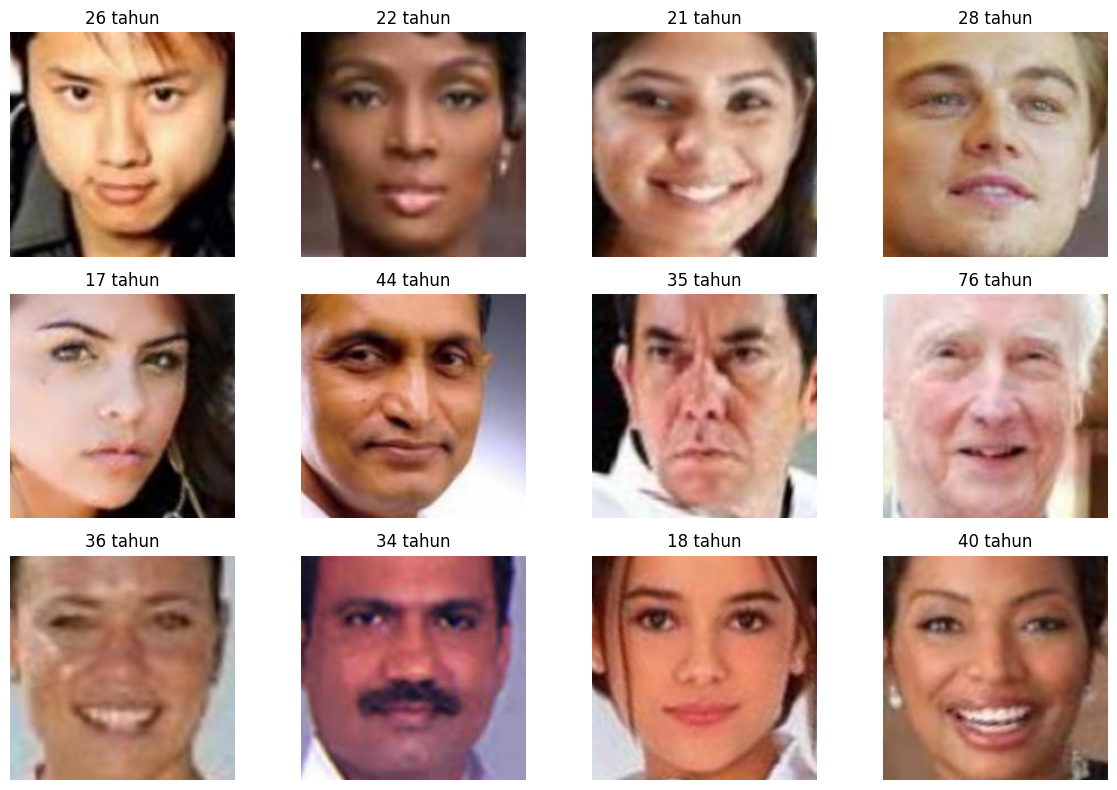

In [23]:
import matplotlib.pyplot as plt
from PIL import Image
import os

plt.figure(figsize=(12, 8))

for i in range(12):
    img = Image.open(files[i])

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(files[i]).split('_')[0] + " tahun")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
def parse_age_from_name(fp):
    return int(os.path.basename(fp).split('_')[0])

ages = np.array(
    [parse_age_from_name(f) for f in files],
    dtype=np.float32
)

print("Jumlah data:", len(files))
print("Jumlah label umur:", len(ages))
print("umur:", ages[:12])

Jumlah data: 66976
Jumlah label umur: 66976
umur: [26. 22. 21. 28. 17. 44. 35. 76. 36. 34. 18. 40.]


In [29]:
from sklearn.model_selection import train_test_split

train_files, test_files, y_train, y_test = train_test_split(
    files,
    ages,
    test_size=0.2,
    random_state=42
)

print("Jumlah data training :", len(train_files))
print("Jumlah data testing  :", len(test_files))
print("Jumlah label training:", len(y_train))
print("Jumlah label testing :", len(y_test))

IMG_SIZE = 160

print("Ukuran gambar:", IMG_SIZE, "x", IMG_SIZE)

def load_img(fp, label):
    img = tf.io.read_file(fp)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    return img / 255.0, label

Jumlah data training : 53580
Jumlah data testing  : 13396
Jumlah label training: 53580
Jumlah label testing : 13396
Ukuran gambar: 160 x 160


In [31]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_files, y_train)
).map(load_img).batch(64)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_files, y_test)
).map(load_img).batch(64)

print("Dataset training dan testing berhasil dibuat.")

for images, labels in train_ds.take(1):
    print("Bentuk gambar :", images.shape)
    print("Bentuk label  :", labels.shape)
    print("Contoh label  :", labels[:10].numpy())

Dataset training dan testing berhasil dibuat.
Bentuk gambar : (64, 160, 160, 3)
Bentuk label  : (64,)
Contoh label  : [24. 28. 67. 56. 25. 20.  4. 63.  1.  3.]


In [32]:
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 berhasil dibuat.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 berhasil dibuat.


In [33]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Preprocessing untuk MobileNetV2
x = tf.keras.applications.mobilenet_v2.preprocess_input(
    inputs * 255.0
)

# Ekstraksi fitur menggunakan MobileNetV2
x = base_model(x, training=False)

# Mengubah feature map menjadi satu vektor
x = layers.GlobalAveragePooling2D()(x)

# Regression head
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)

# Output = 1 angka umur
outputs = layers.Dense(1)(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

print("Model berhasil di-compile.")

Model berhasil di-compile.


In [35]:
cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("EarlyStopping berhasil dibuat.")

EarlyStopping berhasil dibuat.


In [5]:
# ============================================================
# MEMBUAT KEMBALI MODEL MOBILENETV2
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = 160

# Load MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights="imagenet"
)

# Bekukan MobileNetV2 untuk training tahap 1
base_model.trainable = False

# Membuat model regresi umur
inputs = tf.keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = tf.keras.applications.mobilenet_v2.preprocess_input(
    inputs * 255.0
)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="mse",
    metrics=["mae"]
)

# Early stopping
cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("Model berhasil dibuat!")
print("Model siap untuk TRAINING TAHAP 1.")

Model berhasil dibuat!
Model siap untuk TRAINING TAHAP 1.


In [7]:
# ============================================================
# MEMBUAT KEMBALI DATASET TRAINING & TESTING
# ============================================================

import os
import glob
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. Ambil kembali lokasi dataset UTKFace
# ------------------------------------------------------------

import kagglehub

path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Lokasi dataset:")
print(path)

# ------------------------------------------------------------
# 2. Cari semua gambar JPG
# ------------------------------------------------------------

files = glob.glob(
    os.path.join(path, "**", "*.jpg"),
    recursive=True
)

print("Jumlah gambar:", len(files))

# ------------------------------------------------------------
# 3. Ambil umur dari nama file
# ------------------------------------------------------------

def parse_age_from_name(fp):
    return int(os.path.basename(fp).split("_")[0])

ages = np.array(
    [parse_age_from_name(f) for f in files],
    dtype=np.float32
)

print("Jumlah label umur:", len(ages))
print("Contoh umur:", ages[:10])

# ------------------------------------------------------------
# 4. Split training dan testing
# ------------------------------------------------------------

train_files, test_files, y_train, y_test = train_test_split(
    files,
    ages,
    test_size=0.2,
    random_state=42
)

print("Jumlah data training :", len(train_files))
print("Jumlah data testing  :", len(test_files))

# ------------------------------------------------------------
# 5. Ukuran gambar
# ------------------------------------------------------------

IMG_SIZE = 160

# ------------------------------------------------------------
# 6. Fungsi membaca gambar
# ------------------------------------------------------------

def load_img(fp, label):

    img = tf.io.read_file(fp)

    img = tf.image.decode_jpeg(
        img,
        channels=3
    )

    img = tf.image.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )

    img = img / 255.0

    return img, label

# ------------------------------------------------------------
# 7. Buat TensorFlow Dataset
# ------------------------------------------------------------

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_files, y_train)
).map(
    load_img
).batch(64)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_files, y_test)
).map(
    load_img
).batch(64)

# ------------------------------------------------------------
# 8. Cek dataset
# ------------------------------------------------------------

for images, labels in train_ds.take(1):

    print("Bentuk gambar :", images.shape)
    print("Bentuk label  :", labels.shape)
    print("Contoh label  :", labels[:10].numpy())

print()
print("=" * 60)
print("DATASET BERHASIL DIBUAT KEMBALI")
print("=" * 60)

100%|██████████| 331M/331M [00:09<00:00, 35.7MB/s]

Extracting files...


Lokasi dataset:
/root/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1
Jumlah gambar: 66976
Jumlah label umur: 66976
Contoh umur: [37. 20. 11. 47. 50. 39. 62. 34.  3. 18.]
Jumlah data training : 53580
Jumlah data testing  : 13396
Bentuk gambar : (64, 160, 160, 3)
Bentuk label  : (64,)
Contoh label  : [27. 28. 23. 24.  3. 16. 38. 62. 44.  1.]

DATASET BERHASIL DIBUAT KEMBALI


In [5]:
# ============================================================
# SETUP ULANG D2 UTKFACE - SETELAH RUNTIME GPU
# ============================================================

import os
import glob
import numpy as np
import tensorflow as tf
import kagglehub

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers

print("TensorFlow :", tf.__version__)
print(
    "GPU:",
    tf.config.list_physical_devices("GPU")
)

# ============================================================
# 1. LOAD DATASET UTKFACE
# ============================================================

path = kagglehub.dataset_download("jangedoo/utkface-new")

files = glob.glob(
    os.path.join(path, "**", "*.jpg"),
    recursive=True
)

print("Jumlah gambar:", len(files))

# ============================================================
# 2. AMBIL LABEL UMUR
# ============================================================

def parse_age_from_name(fp):
    return int(os.path.basename(fp).split("_")[0])

ages = np.array(
    [parse_age_from_name(f) for f in files],
    dtype=np.float32
)

print("Jumlah label:", len(ages))

# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

train_files, test_files, y_train, y_test = train_test_split(
    files,
    ages,
    test_size=0.2,
    random_state=42
)

print("Training:", len(train_files))
print("Testing :", len(test_files))

# ============================================================
# 4. LOAD GAMBAR
# ============================================================

IMG_SIZE = 160

def load_img(fp, label):

    img = tf.io.read_file(fp)

    img = tf.image.decode_jpeg(
        img,
        channels=3
    )

    img = tf.image.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )

    img = img / 255.0

    return img, label

# ============================================================
# 5. BUAT DATASET
# ============================================================

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_files, y_train)
)

train_ds = train_ds.map(
    load_img,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(128)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)


test_ds = tf.data.Dataset.from_tensor_slices(
    (test_files, y_test)
)

test_ds = test_ds.map(
    load_img,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(128)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print("Dataset berhasil dibuat.")

# ============================================================
# 6. MOBILE NET V2
# ============================================================

base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights="imagenet"
)

base_model.trainable = False

# ============================================================
# 7. MODEL REGRESI UMUR
# ============================================================

inputs = tf.keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = tf.keras.applications.mobilenet_v2.preprocess_input(
    inputs * 255.0
)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

# ============================================================
# 8. COMPILE
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="mse",
    metrics=["mae"]
)

# ============================================================
# 9. EARLY STOPPING
# ============================================================

cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print()
print("=" * 60)
print("SEMUA SETUP BERHASIL")
print("=" * 60)
print("Model       : siap")
print("train_ds    : siap")
print("test_ds     : siap")
print("EarlyStop   : siap")

TensorFlow : 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using Colab cache for faster access to the 'utkface-new' dataset.
Jumlah gambar: 66976
Jumlah label: 66976
Training: 53580
Testing : 13396
Dataset berhasil dibuat.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

SEMUA SETUP BERHASIL
Model       : siap
train_ds    : siap
test_ds     : siap
EarlyStop   : siap


In [9]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from math import sqrt

from tensorflow.keras import layers, models

TRAINING TAHAP 1
Epoch 1/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 49s 116ms/step - loss: 105.7529 - mae: 7.5678 - val_loss: 106.7585 - val_mae: 7.6247
Epoch 2/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 47s 111ms/step - loss: 104.0305 - mae: 7.5033 - val_loss: 106.0121 - val_mae: 7.6308
Epoch 3/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 48s 114ms/step - loss: 102.3510 - mae: 7.4579 - val_loss: 102.8607 - val_mae: 7.4789
Epoch 4/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 49s 116ms/step - loss: 101.1251 - mae: 7.4166 - val_loss: 103.2681 - val_mae: 7.5406
Epoch 5/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 50s 120ms/step - loss: 98.7353 - mae: 7.3227 - val_loss: 101.5226 - val_mae: 7.4520
Epoch 6/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - loss: 97.1515 - mae: 7.2532 - val_loss: 101.8173 - val_mae: 7.5253
Epoch 7/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 47s 112ms/step - loss: 95.2453 - mae: 7.1910 - val_loss: 98.2633 - val_mae: 7.3336
Epoch 8/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 50s 119ms/step - loss: 93.8661 - mae: 7.1379 - val_loss: 97.5598 - val_m

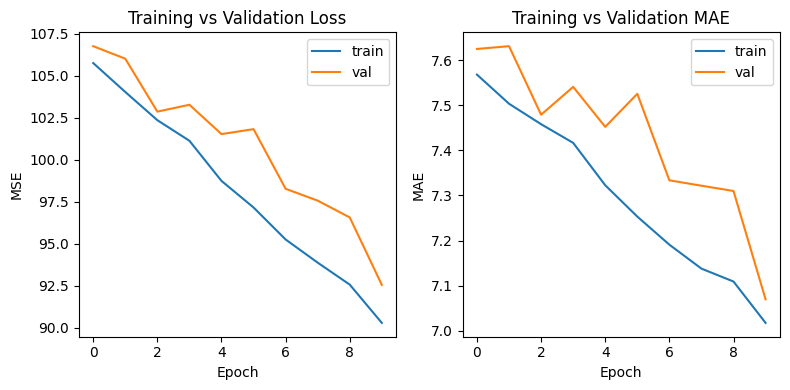

FINE-TUNING
30 layer terakhir dibuka untuk fine-tuning.
Model berhasil di-compile ulang.
Epoch 1/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 86s 163ms/step - loss: 127.5395 - mae: 8.0418 - val_loss: 269.9796 - val_mae: 12.1217
Epoch 2/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 49s 117ms/step - loss: 49.4719 - mae: 5.1684 - val_loss: 132.7492 - val_mae: 8.6117
Epoch 3/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 48s 114ms/step - loss: 33.0441 - mae: 4.2260 - val_loss: 66.9838 - val_mae: 6.1257
Epoch 4/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 48s 114ms/step - loss: 26.1648 - mae: 3.7111 - val_loss: 51.6857 - val_mae: 5.3514
Epoch 5/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 49s 116ms/step - loss: 23.1369 - mae: 3.4589 - val_loss: 35.9421 - val_mae: 4.3839


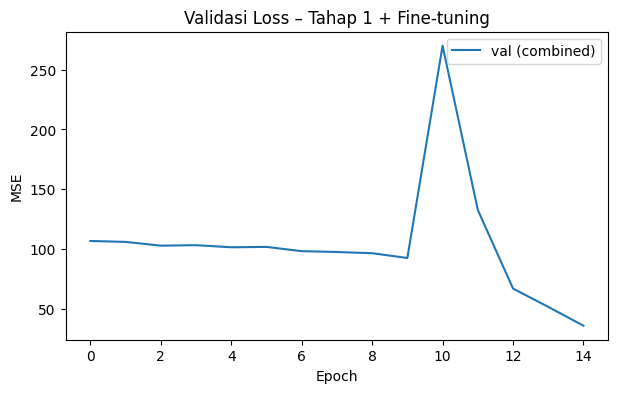

MEMBUAT PREDIKSI
Jumlah prediksi: 13396

HASIL EVALUASI D2
MAE  = 4.38 tahun
RMSE = 6.00 tahun
R²   = 0.923


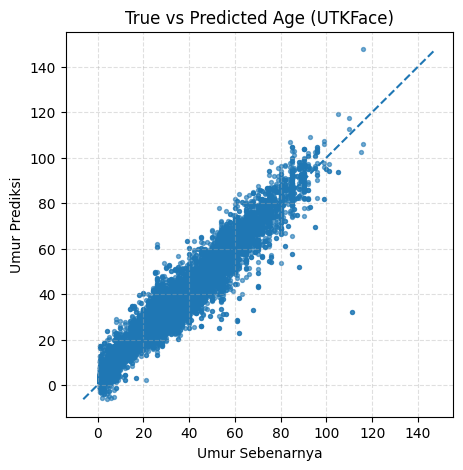

NameError: name 'Image' is not defined

<Figure size 1200x800 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. TRAINING TAHAP 1
# ------------------------------------------------------------
print("=" * 60)
print("TRAINING TAHAP 1")
print("=" * 60)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=[cb],
    verbose=1
)


# ------------------------------------------------------------
# 2. VISUALISASI TRAINING
# ------------------------------------------------------------
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="train")
plt.plot(history.history["val_mae"], label="val")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. FINE-TUNING BACKBONE
# ------------------------------------------------------------
print("=" * 60)
print("FINE-TUNING")
print("=" * 60)

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print("30 layer terakhir dibuka untuk fine-tuning.")


# ------------------------------------------------------------
# 4. COMPILE ULANG DENGAN LEARNING RATE LEBIH KECIL
# ------------------------------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="mse",
    metrics=["mae"]
)

print("Model berhasil di-compile ulang.")


# ------------------------------------------------------------
# 5. TRAINING FINE-TUNING
# ------------------------------------------------------------
history_ft = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    callbacks=[cb],
    verbose=1
)


# ------------------------------------------------------------
# 6. VISUALISASI VALIDATION LOSS GABUNGAN
# ------------------------------------------------------------
plt.figure(figsize=(7, 4))

plt.plot(
    history.history["val_loss"] + history_ft.history["val_loss"],
    label="val (combined)"
)

plt.title("Validasi Loss – Tahap 1 + Fine-tuning")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()


# ------------------------------------------------------------
# 7. PREDIKSI DATA TESTING
# ------------------------------------------------------------
print("=" * 60)
print("MEMBUAT PREDIKSI")
print("=" * 60)

y_pred = np.concatenate([
    model.predict(batch[0], verbose=0).ravel()
    for batch in test_ds
])

print("Jumlah prediksi:", len(y_pred))


# ------------------------------------------------------------
# 8. EVALUASI MAE, RMSE, R²
# ------------------------------------------------------------
from sklearn.metrics import mean_absolute_error, r2_score
from math import sqrt

mae = mean_absolute_error(y_test, y_pred)

rmse = sqrt(
    np.mean((y_test - y_pred) ** 2)
)

r2 = r2_score(y_test, y_pred)

print()
print("=" * 60)
print("HASIL EVALUASI D2")
print("=" * 60)
print(f"MAE  = {mae:.2f} tahun")
print(f"RMSE = {rmse:.2f} tahun")
print(f"R²   = {r2:.3f}")


# ------------------------------------------------------------
# 9. TRUE VS PREDICTED
# ------------------------------------------------------------
plt.figure(figsize=(5, 5))

plt.scatter(
    y_test,
    y_pred,
    s=8,
    alpha=0.6
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

plt.plot(
    lims,
    lims,
    "--"
)

plt.xlabel("Umur Sebenarnya")
plt.ylabel("Umur Prediksi")
plt.title("True vs Predicted Age (UTKFace)")

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.show()


# ------------------------------------------------------------
# 10. CONTOH PREDIKSI PADA FOTO
# ------------------------------------------------------------
plt.figure(figsize=(12, 8))

for i in range(12):
    img = Image.open(test_files[i])

    true_age = y_test[i]
    predicted_age = y_pred[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(img)

    plt.title(
        f"True: {true_age:.0f}\n"
        f"Pred: {predicted_age:.1f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# SELESAI
# ------------------------------------------------------------
print()
print("=" * 60)
print("D2 SELESAI")
print("=" * 60)
print(f"MAE  : {mae:.2f} tahun")
print(f"RMSE : {rmse:.2f} tahun")
print(f"R²   : {r2:.3f}")

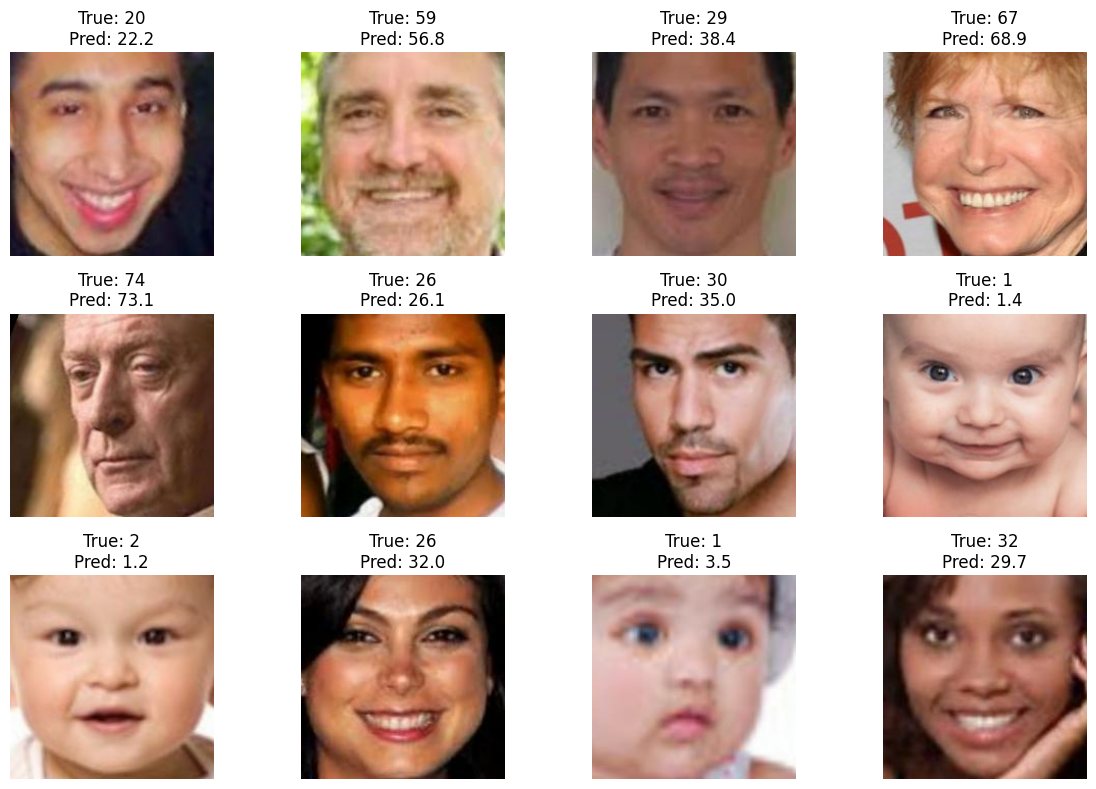

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(12):
    img = Image.open(test_files[i])

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(
        f"True: {y_test[i]:.0f}\n"
        f"Pred: {y_pred[i]:.1f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

HASIL EVALUASI D2
MAE  = 4.38 tahun
RMSE = 6.00 tahun
R²   = 0.923


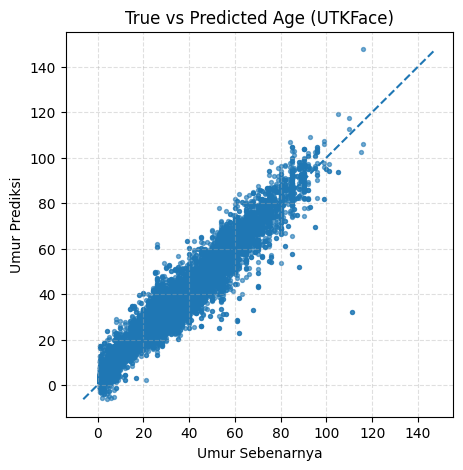

In [12]:
# ============================================================
# EVALUASI D2 - UTKFace
# ============================================================

from sklearn.metrics import mean_absolute_error, r2_score
from math import sqrt

mae = mean_absolute_error(y_test, y_pred)

rmse = sqrt(
    np.mean((y_test - y_pred) ** 2)
)

r2 = r2_score(
    y_test,
    y_pred
)

print("=" * 60)
print("HASIL EVALUASI D2")
print("=" * 60)

print(f"MAE  = {mae:.2f} tahun")
print(f"RMSE = {rmse:.2f} tahun")
print(f"R²   = {r2:.3f}")

# ============================================================
# TRUE VS PREDICTED AGE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

plt.scatter(
    y_test,
    y_pred,
    s=8,
    alpha=0.6
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

plt.plot(
    lims,
    lims,
    "--"
)

plt.xlabel("Umur Sebenarnya")
plt.ylabel("Umur Prediksi")
plt.title("True vs Predicted Age (UTKFace)")
plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.show()

In [13]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
!pip -q install kagglehub

In [15]:
import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [18]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [19]:
import kagglehub

path = kagglehub.dataset_download(
    "user164919/the-dogage-dataset"
)

print("Dataset berhasil di-download!")
print("Lokasi:", path)

100%|██████████| 1.65G/1.65G [00:25<00:00, 70.6MB/s]

Extracting files...


Dataset berhasil di-download!
Lokasi: /root/.cache/kagglehub/datasets/user164919/the-dogage-dataset/versions/1


In [20]:
import os

print(os.listdir(path))

for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Jumlah subfolder:", len(dirs))
    print("Jumlah file:", len(files))
    print()

    if root.count(os.sep) - path.count(os.sep) >= 2:
        dirs[:] = []

['PetFinder_All', 'Expert_Train']
Folder: /root/.cache/kagglehub/datasets/user164919/the-dogage-dataset/versions/1
Jumlah subfolder: 2
Jumlah file: 0

Folder: /root/.cache/kagglehub/datasets/user164919/the-dogage-dataset/versions/1/PetFinder_All
Jumlah subfolder: 1
Jumlah file: 0

Folder: /root/.cache/kagglehub/datasets/user164919/the-dogage-dataset/versions/1/PetFinder_All/PetFinder_All
Jumlah subfolder: 3
Jumlah file: 0

Folder: /root/.cache/kagglehub/datasets/user164919/the-dogage-dataset/versions/1/Expert_Train
Jumlah subfolder: 1
Jumlah file: 0

Folder: /root/.cache/kagglehub/datasets/user164919/the-dogage-dataset/versions/1/Expert_Train/Expert_TrainEval
Jumlah subfolder: 3
Jumlah file: 0



In [21]:
import os

expert_path = os.path.join(path, "Expert_Train")

print("Isi Expert_Train:")
print(os.listdir(expert_path))

Isi Expert_Train:
['Expert_TrainEval']


In [22]:
for root, dirs, files in os.walk(expert_path):
    print("\nFolder:", root)
    print("Subfolder:", dirs)
    print("Jumlah file:", len(files))

    # Jangan tampilkan terlalu dalam
    if root.count(os.sep) - expert_path.count(os.sep) >= 3:
        dirs[:] = []


Folder: /root/.cache/kagglehub/datasets/user164919/the-dogage-dataset/versions/1/Expert_Train
Subfolder: ['Expert_TrainEval']
Jumlah file: 0

Folder: /root/.cache/kagglehub/datasets/user164919/the-dogage-dataset/versions/1/Expert_Train/Expert_TrainEval
Subfolder: ['Senior', 'Adult', 'Young']
Jumlah file: 0

Folder: /root/.cache/kagglehub/datasets/user164919/the-dogage-dataset/versions/1/Expert_Train/Expert_TrainEval/Senior
Subfolder: []
Jumlah file: 495

Folder: /root/.cache/kagglehub/datasets/user164919/the-dogage-dataset/versions/1/Expert_Train/Expert_TrainEval/Adult
Subfolder: []
Jumlah file: 370

Folder: /root/.cache/kagglehub/datasets/user164919/the-dogage-dataset/versions/1/Expert_Train/Expert_TrainEval/Young
Subfolder: []
Jumlah file: 223


In [23]:
import os
import pandas as pd

# Lokasi dataset Expert
expert_eval_path = os.path.join(
    path,
    "Expert_Train",
    "Expert_TrainEval"
)

# Mapping kategori menjadi target numerik
label_map = {
    "Young": 1.0,
    "Adult": 2.0,
    "Senior": 3.0
}

data = []

for category, label in label_map.items():

    folder = os.path.join(
        expert_eval_path,
        category
    )

    for filename in os.listdir(folder):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            data.append({
                "image_path": os.path.join(
                    folder,
                    filename
                ),
                "category": category,
                "target": label
            })

df = pd.DataFrame(data)

print("Total gambar:", len(df))
print()
print(df["category"].value_counts())
print()
display(df.head())

Total gambar: 1088

category
Senior    495
Adult     370
Young     223
Name: count, dtype: int64



,image_path,category,target
0,/root/.cache/kagglehub/datasets/user164919/the...,Young,1.0
1,/root/.cache/kagglehub/datasets/user164919/the...,Young,1.0
2,/root/.cache/kagglehub/datasets/user164919/the...,Young,1.0
3,/root/.cache/kagglehub/datasets/user164919/the...,Young,1.0
4,/root/.cache/kagglehub/datasets/user164919/the...,Young,1.0


In [24]:
print(df.shape)
print()
print(df["category"].value_counts())
print()
print(df["target"].value_counts().sort_index())

(1088, 3)

category
Senior    495
Adult     370
Young     223
Name: count, dtype: int64

target
1.0    223
2.0    370
3.0    495
Name: count, dtype: int64


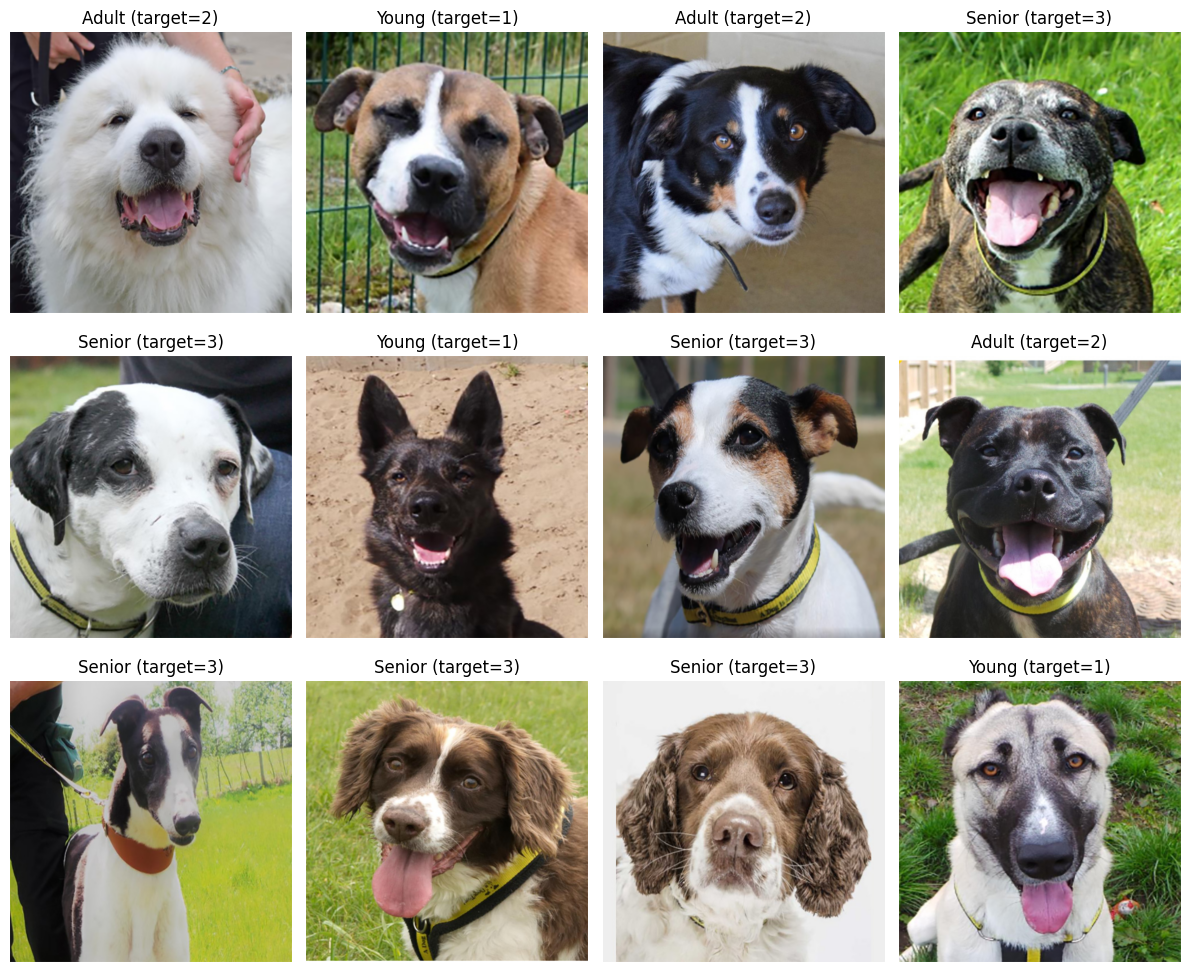

In [25]:
import matplotlib.pyplot as plt
from PIL import Image

sample_df = df.sample(
    12,
    random_state=42
)

plt.figure(figsize=(12, 10))

for i, (_, row) in enumerate(
    sample_df.iterrows()
):

    img = Image.open(
        row["image_path"]
    )

    plt.subplot(3, 4, i + 1)

    plt.imshow(img)

    plt.title(
        f"{row['category']} "
        f"(target={row['target']:.0f})"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["category"]
)

print("Training   :", len(train_df))
print("Validation :", len(val_df))

Training   : 870
Validation : 218


In [29]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32
def load_image(path, label):

    img = tf.io.read_file(path)

    img = tf.image.decode_image(
        img,
        channels=3,
        expand_animations=False
    )

    img = tf.image.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )

    img = tf.cast(
        img,
        tf.float32
    ) / 255.0

    return img, label
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["target"].values.astype("float32")
    )
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["target"].values.astype("float32")
    )
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )
    .shuffle(500)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("✅ TensorFlow Dataset siap")

✅ TensorFlow Dataset siap


In [31]:
# ============================================================
# IMPORT LIBRARY UNTUK MODEL
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

print("✅ Semua library berhasil di-import")
print("TensorFlow:", tf.__version__)

✅ Semua library berhasil di-import
TensorFlow: 2.20.0


✅ TensorFlow Dataset siap

================ MEMBUAT MODEL ================
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ EfficientNetB0 berhasil dibuat
✅ Backbone dalam kondisi frozen
✅ Regression head berhasil dibuat
✅ Model berhasil di-compile

================ MODEL SUMMARY ================


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ age_score (Dense)               │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

✅ Callback siap

================ TRAINING MODEL ================
Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - loss: 1.1751 - mae: 0.8644 - val_loss: 0.6266 - val_mae: 0.6681 - learning_rate: 0.0010
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.6355 - mae: 0.6856 - val_loss: 0.6635 - val_mae: 0.7066 - learning_rate: 0.0010
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.6465 - mae: 0.6854 - val_loss: 0.6214 - val_mae: 0.6969 - learning_rate: 0.0010
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - loss: 0.6521 - mae: 0.6904 - val_loss: 0.6049 - val_mae: 0.6764 - learning_rate: 0.0010
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - loss: 0.6465 - mae: 0.6971 - val_loss: 0.6074 - val_mae: 0.6751 - learning_rate: 0.0010
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.6133 - mae: 0.6845 - val_loss: 0.6043 - val_mae: 0.6898 - learning_rate: 0.0010
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - loss: 0.6226 - mae: 0.6858 - val_

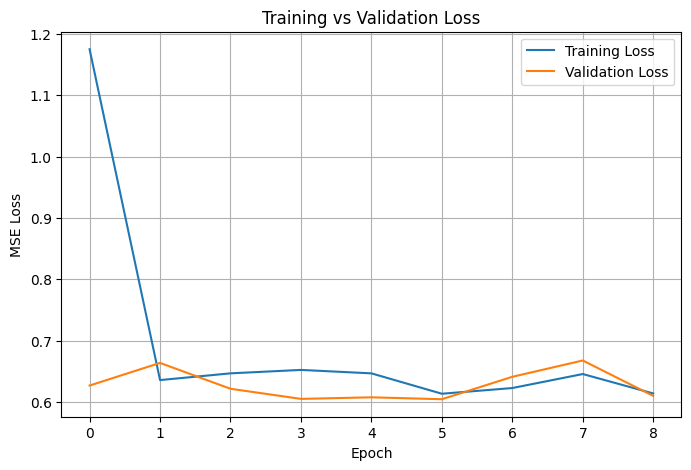

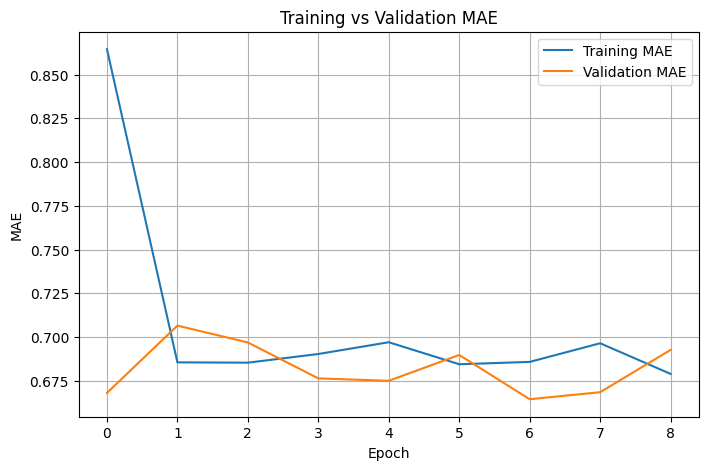


================ EVALUASI MODEL ================
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step

Hasil Evaluasi:
----------------------------
MAE  : 0.6898
RMSE : 0.7774
R²   : -0.0086
----------------------------


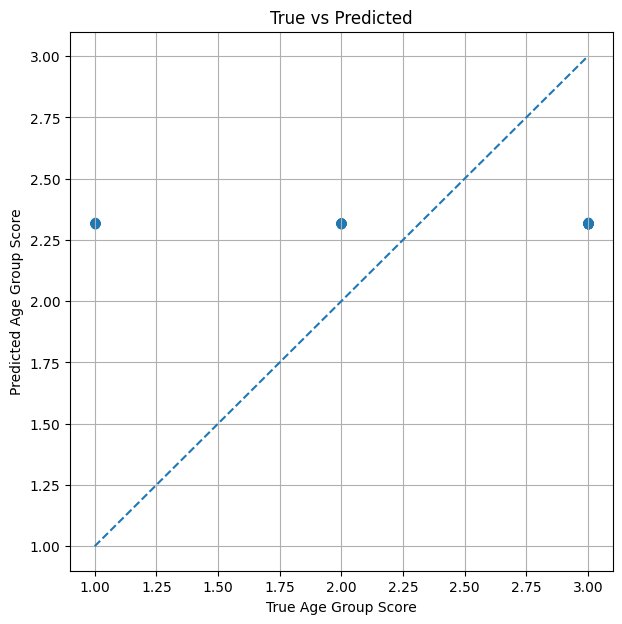


================ SAMPLE PREDICTIONS ================


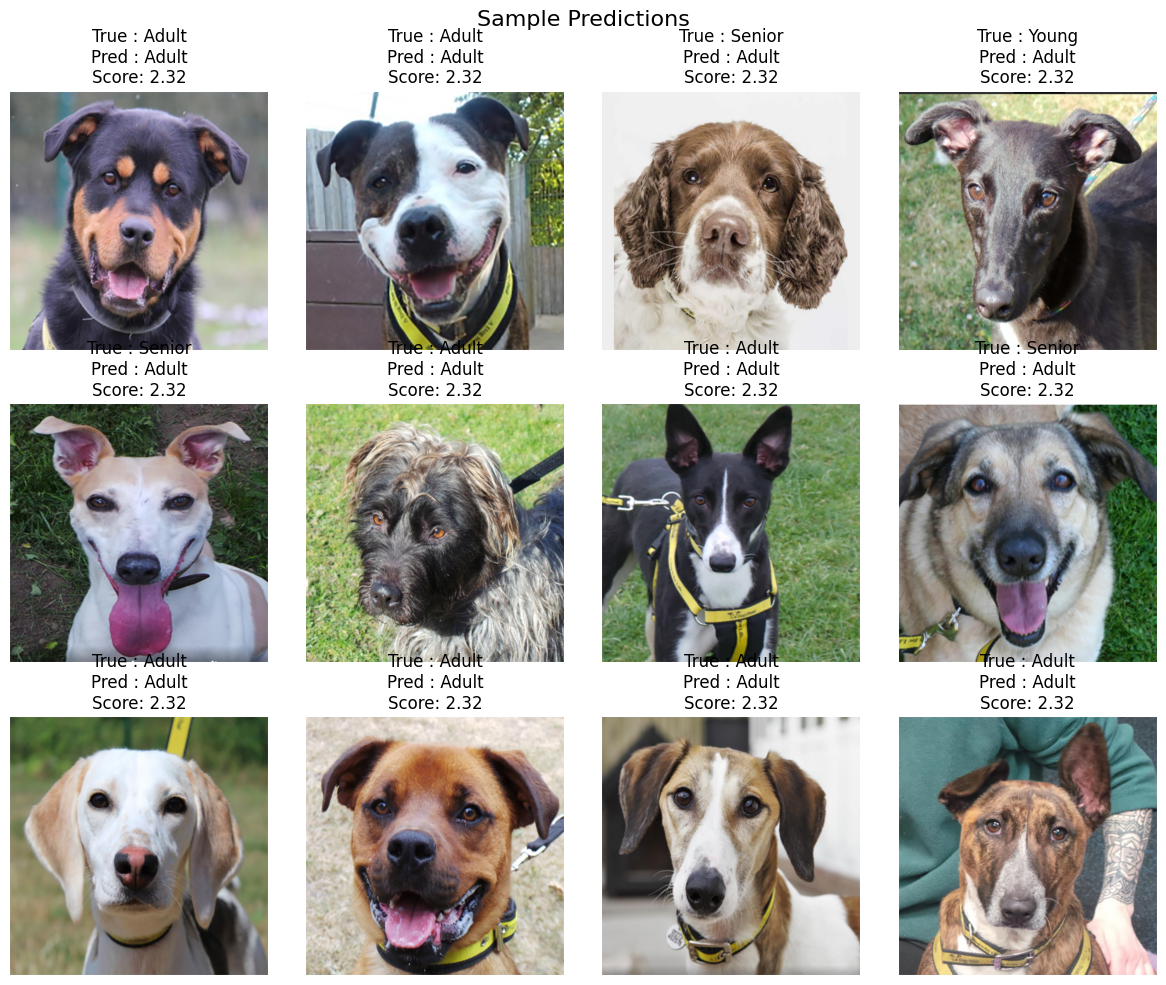

,Image,True Category,True Score,Predicted Score,Predicted Category
0,/root/.cache/kagglehub/datasets/user164919/the...,Adult,2.0,2.318411,Adult
1,/root/.cache/kagglehub/datasets/user164919/the...,Adult,2.0,2.319505,Adult
2,/root/.cache/kagglehub/datasets/user164919/the...,Senior,3.0,2.318937,Adult
3,/root/.cache/kagglehub/datasets/user164919/the...,Young,1.0,2.320001,Adult
4,/root/.cache/kagglehub/datasets/user164919/the...,Senior,3.0,2.319719,Adult
5,/root/.cache/kagglehub/datasets/user164919/the...,Adult,2.0,2.316155,Adult
6,/root/.cache/kagglehub/datasets/user164919/the...,Adult,2.0,2.317147,Adult
7,/root/.cache/kagglehub/datasets/user164919/the...,Senior,3.0,2.319508,Adult
8,/root/.cache/kagglehub/datasets/user164919/the...,Adult,2.0,2.319961,Adult
9,/root/.cache/kagglehub/datasets/user164919/the...,Adult,2.0,2.319191,Adult


Akurasi kategori pada 12 sample: 66.67%


                 HASIL AKHIR D3
Total dataset       : 1088 gambar
Data training       : 870 gambar
Data validation     : 218 gambar

Model:
EfficientNetB0
Transfer Learning
ImageNet pretrained weights

Regression Head:
GlobalAveragePooling2D
Dropout(0.3)
Dense(256, ReLU)
Dense(1)

Evaluation:
MAE  : 0.6898
RMSE : 0.7774
R²   : -0.0086

Target Mapping:
Young  = 1
Adult  = 2
Senior = 3

CATATAN:
Target merupakan skor ordinal kelompok usia, bukan umur anjing dalam satuan tahun.


In [32]:
# ============================================================
# 11. MEMBUAT TF.DATASET
# ============================================================

train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["target"].values.astype("float32")
    )
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["target"].values.astype("float32")
    )
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )
    .shuffle(500)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("✅ TensorFlow Dataset siap")


# ============================================================
# 12. MEMBUAT MODEL EfficientNetB0
# ============================================================

print("\n================ MEMBUAT MODEL ================")

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone
base_model.trainable = False

print("✅ EfficientNetB0 berhasil dibuat")
print("✅ Backbone dalam kondisi frozen")


# ============================================================
# 13. MEMBUAT REGRESSION HEAD
# ============================================================

inputs = tf.keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Masukkan gambar ke EfficientNet
x = base_model(
    inputs,
    training=False
)

# Mengubah feature map menjadi vector
x = layers.GlobalAveragePooling2D()(x)

# Dropout untuk mengurangi overfitting
x = layers.Dropout(0.3)(x)

# Fully connected layer
x = layers.Dense(
    256,
    activation="relu"
)(x)

# Output regresi
# Hanya 1 neuron karena target berupa angka
outputs = layers.Dense(
    1,
    name="age_score"
)(x)

# Gabungkan menjadi model
model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

print("✅ Regression head berhasil dibuat")


# ============================================================
# 14. COMPILE MODEL
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="mse",
    metrics=["mae"]
)

print("✅ Model berhasil di-compile")


# ============================================================
# 15. MODEL SUMMARY
# ============================================================

print("\n================ MODEL SUMMARY ================")

model.summary()


# ============================================================
# 16. CALLBACKS
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    patience=2,
    factor=0.5,
    min_lr=1e-7,
    verbose=1
)

callbacks = [
    early_stopping,
    reduce_lr
]

print("✅ Callback siap")


# ============================================================
# 17. TRAINING MODEL
# ============================================================

print("\n================ TRAINING MODEL ================")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training selesai")


# ============================================================
# 18. GRAFIK TRAINING LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 19. GRAFIK MAE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["mae"],
    label="Training MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.title(
    "Training vs Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 20. EVALUASI MODEL
# ============================================================

print("\n================ EVALUASI MODEL ================")

# Nilai sebenarnya
y_true = np.concatenate([
    y.numpy()
    for _, y in val_ds
])

# Prediksi model
y_pred = model.predict(
    val_ds,
    verbose=1
).ravel()

# MAE
mae = mean_absolute_error(
    y_true,
    y_pred
)

# RMSE
rmse = np.sqrt(
    np.mean(
        (y_true - y_pred) ** 2
    )
)

# R²
r2 = r2_score(
    y_true,
    y_pred
)

print("\nHasil Evaluasi:")
print("----------------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print("----------------------------")


# ============================================================
# 21. TRUE VS PREDICTED
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_true,
    y_pred,
    alpha=0.6
)

# Garis prediksi ideal
min_value = min(
    y_true.min(),
    y_pred.min()
)

max_value = max(
    y_true.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel(
    "True Age Group Score"
)

plt.ylabel(
    "Predicted Age Group Score"
)

plt.title(
    "True vs Predicted"
)

plt.grid(True)

plt.show()


# ============================================================
# 22. FUNCTION KONVERSI SCORE → CATEGORY
# ============================================================

def score_to_category(score):

    if score < 1.5:
        return "Young"

    elif score < 2.5:
        return "Adult"

    else:
        return "Senior"


# ============================================================
# 23. SAMPLE PREDICTIONS
# ============================================================

print("\n================ SAMPLE PREDICTIONS ================")

sample_prediction_df = val_df.sample(
    12,
    random_state=10
).reset_index(drop=True)

sample_paths = sample_prediction_df[
    "image_path"
].values

sample_targets = sample_prediction_df[
    "target"
].values.astype("float32")


sample_ds = tf.data.Dataset.from_tensor_slices(
    (
        sample_paths,
        sample_targets
    )
)

sample_ds = (
    sample_ds
    .map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
)


# Prediksi
sample_predictions = model.predict(
    sample_ds,
    verbose=0
).ravel()


# ============================================================
# 24. VISUALISASI SAMPLE PREDICTIONS
# ============================================================

plt.figure(figsize=(12, 10))

for i in range(
    len(sample_prediction_df)
):

    row = sample_prediction_df.iloc[i]

    img = Image.open(
        row["image_path"]
    )

    true_category = row["category"]

    true_score = row["target"]

    predicted_score = sample_predictions[i]

    predicted_category = score_to_category(
        predicted_score
    )

    plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(img)

    plt.title(
        f"True : {true_category}\n"
        f"Pred : {predicted_category}\n"
        f"Score: {predicted_score:.2f}"
    )

    plt.axis("off")


plt.suptitle(
    "Sample Predictions",
    fontsize=16
)

plt.tight_layout()

plt.show()


# ============================================================
# 25. TABEL HASIL PREDIKSI
# ============================================================

result_df = pd.DataFrame({
    "Image": sample_prediction_df["image_path"],
    "True Category": sample_prediction_df["category"],
    "True Score": sample_prediction_df["target"],
    "Predicted Score": sample_predictions
})

result_df["Predicted Category"] = (
    result_df["Predicted Score"]
    .apply(score_to_category)
)

display(result_df)


# ============================================================
# 26. AKURASI KATEGORI TAMBAHAN
# ============================================================

# Walaupun tugas utamanya REGRESI,
# kita bisa melihat berapa prediksi kategori
# yang kebetulan sesuai dengan label aslinya.

category_accuracy = np.mean(
    result_df["True Category"]
    ==
    result_df["Predicted Category"]
)

print(
    f"Akurasi kategori pada 12 sample: "
    f"{category_accuracy * 100:.2f}%"
)


# ============================================================
# 27. RINGKASAN HASIL AKHIR
# ============================================================

print("\n")
print("======================================================")
print("                 HASIL AKHIR D3")
print("======================================================")

print(f"Total dataset       : {len(df)} gambar")
print(f"Data training       : {len(train_df)} gambar")
print(f"Data validation     : {len(val_df)} gambar")

print("\nModel:")
print("EfficientNetB0")
print("Transfer Learning")
print("ImageNet pretrained weights")

print("\nRegression Head:")
print("GlobalAveragePooling2D")
print("Dropout(0.3)")
print("Dense(256, ReLU)")
print("Dense(1)")

print("\nEvaluation:")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

print("\nTarget Mapping:")
print("Young  = 1")
print("Adult  = 2")
print("Senior = 3")

print("\nCATATAN:")
print(
    "Target merupakan skor ordinal kelompok usia, "
    "bukan umur anjing dalam satuan tahun."
)

print("======================================================")

In [33]:
# ============================================================
# FINE-TUNING EfficientNetB0
# ============================================================

print("==============================================")
print("          MULAI FINE-TUNING")
print("==============================================")


# ------------------------------------------------------------
# 1. Buka kembali beberapa layer terakhir EfficientNet
# ------------------------------------------------------------

base_model.trainable = True


# Kita freeze sebagian besar layer,
# hanya layer terakhir yang akan dilatih.

for layer in base_model.layers[:-20]:
    layer.trainable = False


print("Total layer EfficientNet :", len(base_model.layers))
print("Layer yang di-fine-tune  : 20")


# ------------------------------------------------------------
# 2. Compile ulang dengan learning rate kecil
# ------------------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="mse",
    metrics=["mae"]
)


print("✅ Model berhasil di-compile ulang")
print("Learning rate = 1e-5")


# ------------------------------------------------------------
# 3. Callback
# ------------------------------------------------------------

early_stopping_ft = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_ft = ReduceLROnPlateau(
    monitor="val_loss",
    patience=2,
    factor=0.5,
    min_lr=1e-7,
    verbose=1
)


# ------------------------------------------------------------
# 4. Fine-tuning
# ------------------------------------------------------------

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        early_stopping_ft,
        reduce_lr_ft
    ],
    verbose=1
)


print("\n✅ Fine-tuning selesai")

          MULAI FINE-TUNING
Total layer EfficientNet : 238
Layer yang di-fine-tune  : 20
✅ Model berhasil di-compile ulang
Learning rate = 1e-5
Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 56s 997ms/step - loss: 5.1972 - mae: 2.0332 - val_loss: 0.6173 - val_mae: 0.6956 - learning_rate: 1.0000e-05
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 3.0630 - mae: 1.5328 - val_loss: 0.6414 - val_mae: 0.7021 - learning_rate: 1.0000e-05
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 2.2263 - mae: 1.2949
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - loss: 2.0140 - mae: 1.2223 - val_loss: 0.6901 - val_mae: 0.7109 - learning_rate: 1.0000e-05
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 1.3871 - mae: 1.0235 - val_loss: 0.7319 - val_mae: 0.7167 - learning_rate: 5.0000e-06
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 1.2731 - mae: 0.9854
Epoch 5: ReduceLROnPlateau reducing learning ra

In [34]:
# ============================================================
# EVALUASI SETELAH FINE-TUNING
# ============================================================

y_true = np.concatenate([
    y.numpy()
    for _, y in val_ds
])

y_pred = model.predict(
    val_ds,
    verbose=1
).ravel()


# MAE
mae_ft = mean_absolute_error(
    y_true,
    y_pred
)


# RMSE
rmse_ft = np.sqrt(
    np.mean(
        (y_true - y_pred) ** 2
    )
)


# R2
r2_ft = r2_score(
    y_true,
    y_pred
)


print("\n==============================================")
print("       HASIL SETELAH FINE-TUNING")
print("==============================================")

print(f"MAE  : {mae_ft:.4f}")
print(f"RMSE : {rmse_ft:.4f}")
print(f"R²   : {r2_ft:.4f}")

print("==============================================")

7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step

       HASIL SETELAH FINE-TUNING
MAE  : 0.6956
RMSE : 0.7857
R²   : -0.0302


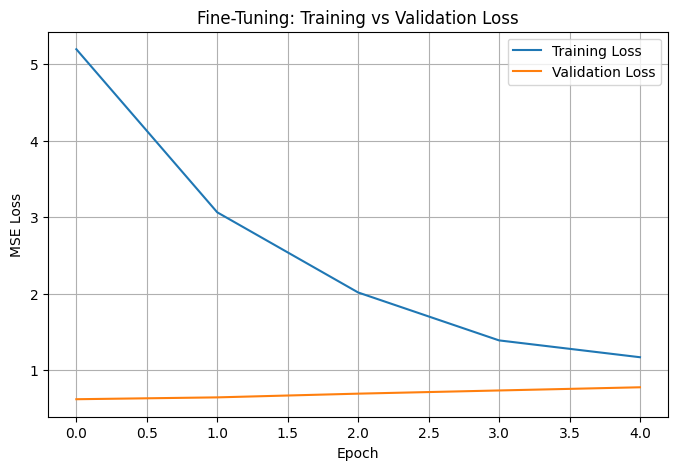

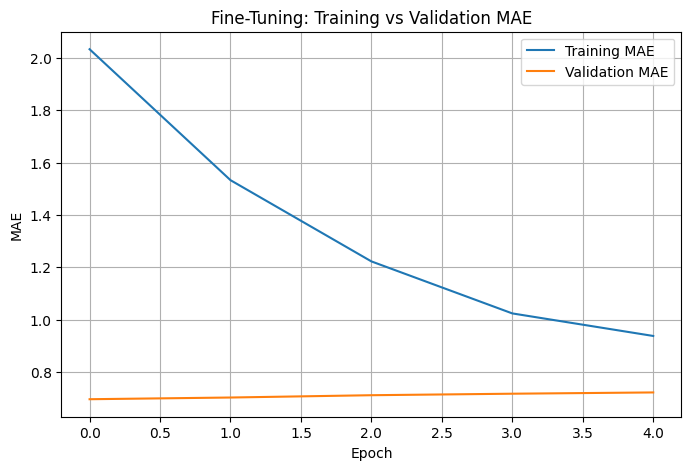

In [35]:
# ============================================================
# GRAFIK FINE-TUNING
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_ft.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_ft.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Fine-Tuning: Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# GRAFIK MAE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_ft.history["mae"],
    label="Training MAE"
)

plt.plot(
    history_ft.history["val_mae"],
    label="Validation MAE"
)

plt.title(
    "Fine-Tuning: Training vs Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE")

plt.legend()
plt.grid(True)

plt.show()

Saving WhatsApp Image 2026-09-19 at 11.26.10.jpeg to WhatsApp Image 2026-09-19 at 11.26.10.jpeg
Foto yang dipilih: WhatsApp Image 2026-09-19 at 11.26.10.jpeg


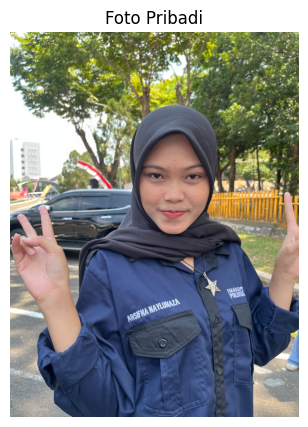


       HASIL PREDIKSI FOTO PRIBADI
Prediksi usia: -9.01 tahun


In [36]:
# ============================================================
# UJI FOTO PRIBADI - PREDIKSI USIA
# ============================================================

from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Upload foto pribadi
uploaded = files.upload()

# Ambil nama file
image_path = list(uploaded.keys())[0]

print("Foto yang dipilih:", image_path)


# ============================================================
# LOAD FOTO
# ============================================================

img = Image.open(image_path).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Foto Pribadi")
plt.axis("off")
plt.show()


# ============================================================
# PREPROCESS FOTO
# ============================================================

IMG_SIZE = 224

img_resized = img.resize(
    (IMG_SIZE, IMG_SIZE)
)

img_array = np.array(
    img_resized
).astype("float32")


# Tambahkan batch dimension
img_input = np.expand_dims(
    img_array,
    axis=0
)


# ============================================================
# PREDIKSI
# ============================================================

prediction = model.predict(
    img_input,
    verbose=0
)

predicted_age = float(
    prediction[0][0]
)


# ============================================================
# HASIL
# ============================================================

print("\n==========================================")
print("       HASIL PREDIKSI FOTO PRIBADI")
print("==========================================")
print(
    f"Prediksi usia: {predicted_age:.2f} tahun"
)
print("==========================================")

Saving kucing-v.jpeg to kucing-v (1).jpeg


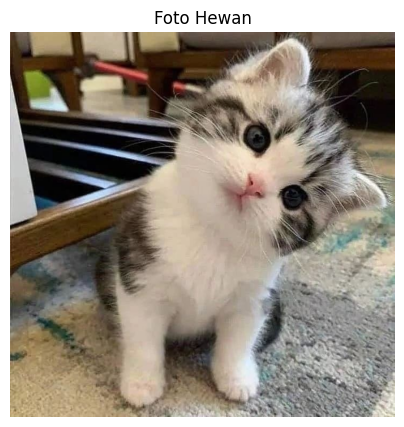

HASIL PREDIKSI HEWAN
Predicted score : 1.00
Age group       : Young


In [39]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Upload foto hewan
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Buka gambar
img = Image.open(image_path).convert("RGB")

# Tampilkan foto asli
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Foto Hewan")
plt.axis("off")
plt.show()

IMG_SIZE = 224

# Resize gambar
img_resized = img.resize((IMG_SIZE, IMG_SIZE))

# Ubah menjadi array
img_array = np.array(img_resized).astype("float32")

# Tambahkan batch dimension
img_input = np.expand_dims(img_array, axis=0)

# Prediksi
prediction = model.predict(img_input, verbose=0)

predicted_score = float(prediction[0][0])

# Batasi hasil ke rentang 1-3
predicted_score = np.clip(predicted_score, 1, 3)

# Konversi ke kelompok umur
if predicted_score < 1.5:
    age_group = "Young"
elif predicted_score < 2.5:
    age_group = "Adult"
else:
    age_group = "Senior"

print("================================")
print("HASIL PREDIKSI HEWAN")
print("================================")
print(f"Predicted score : {predicted_score:.2f}")
print(f"Age group       : {age_group}")
print("================================")